# Quantitative Derivatives & Risk — Model Notebook

A full derivatives-desk stack, from closed-form pricing to stochastic-local-vol, run on synthetic and live (Yahoo Finance) data.

| § | Model | Core idea |
|---|---|---|
| 1 | Black–Scholes–Merton | Lognormal spot, constant vol, Greeks |
| 2 | Heston | Stochastic variance, semi-analytic Fourier pricing |
| 3 | Andersen QE | Unbiased Heston simulation when Feller fails |
| 4 | Calibration | Fit Heston to an implied-vol surface |
| 5 | Monte Carlo exotics | Asian & barrier options, variance reduction |
| 6 | Delta hedging | Gamma/theta P&L and realised vs implied vol |
| 7 | Portfolio risk | Full-revaluation VaR / ES, scenario grids |
| 8 | Stat-arb | Ornstein–Uhlenbeck pairs trading |
| 9 | SVI | Arbitrage-free implied-vol surface |
| 10 | Dupire local vol | Vol as a function of spot and time |
| 11 | Heston-SLV | Local vol × stochastic vol, particle calibration |
| 12 | Live market | All of the above on a real option chain |
| 13 | SABR | Rates/FX smile standard, Hagan expansion |
| 14 | Rough Bergomi | Rough volatility, ATM-skew power law, H from market |
| 15 | Hull–White | Short-rate model on the live Treasury curve, caps & swaptions |
| 16 | Jump-diffusion | Merton & Kou, crash risk, short-dated skew |

All model code lives in `quant_model.py` and `market_data.py`; this notebook imports it, explains the math and draws the pictures.

In [1]:
# ── Environment check: run this first ──
import sys, os, importlib.util
need = ["numpy", "scipy", "pandas", "matplotlib", "yfinance"]
missing = [m for m in need if importlib.util.find_spec(m) is None]
if missing:
    raise ImportError(f"Missing packages {missing}. Run in a cell:  %pip install {' '.join(missing)}")
if importlib.util.find_spec("quant_model") is None:
    raise ImportError("quant_model.py not found: open this notebook from the Quant_Portfolio folder "
                      f"(current folder: {os.getcwd()})")
print(f"OK: Python {sys.version.split()[0]} at {sys.executable}\n    working folder {os.getcwd()}")

OK: Python 3.14.5 at C:\Users\caspe\AppData\Local\Python\pythoncore-3.14-64\python.exe
    working folder C:\Users\caspe\OneDrive\Skrivebord\Quant_Portfolio


In [2]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.stats import norm

import quant_model as qm
from quant_model import (bs_price, bs_greeks, implied_vol, HestonParams, heston_price,
                         heston_paths, heston_paths_qe, calibrate_heston, mc_price,
                         delta_hedge_pnl, Position, portfolio_value, var_es,
                         simulate_pair, fit_ou, pairs_backtest, SVISurface, svi_w,
                         butterfly_g, lv_paths, slv_paths)

plt.rcParams.update({"figure.figsize": (11, 4.2), "figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 10, "axes.titleweight": "bold"})
C = plt.rcParams["axes.prop_cycle"].by_key()["color"]
qm.RNG = np.random.default_rng(7)          # reproducible

S, r, q = 100.0, 0.045, 0.012
true = HestonParams(v0=0.04, kappa=1.8, theta=0.05, xi=0.6, rho=-0.7)

## 1 · Black–Scholes–Merton

Under the risk-neutral measure $\mathbb{Q}$ the spot follows geometric Brownian motion with continuous carry $q$:

$$
dS_t = (r-q)\,S_t\,dt + \sigma S_t\,dW_t^{\mathbb{Q}}
$$

No-arbitrage (delta-hedging away $dW$) gives the **Black–Scholes PDE**

$$
\frac{\partial V}{\partial t} + \tfrac12\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2} + (r-q)S\frac{\partial V}{\partial S} - rV = 0,
$$

whose solution for a European call/put ($\phi=\pm1$) is

$$
V = \phi\left[S e^{-qT}\,N(\phi d_1) - K e^{-rT}\,N(\phi d_2)\right],\qquad
d_{1,2} = \frac{\ln(S/K) + (r-q\pm\tfrac12\sigma^2)T}{\sigma\sqrt T}.
$$

**Greeks** — the hedge ratios a desk actually runs:

$$
\Delta = \phi e^{-qT}N(\phi d_1),\quad
\Gamma = \frac{e^{-qT}n(d_1)}{S\sigma\sqrt T},\quad
\mathcal{V} = S e^{-qT} n(d_1)\sqrt T,\quad
\text{Vanna} = -e^{-qT} n(d_1)\frac{d_2}{\sigma},\quad
\text{Volga} = \mathcal{V}\,\frac{d_1 d_2}{\sigma}
$$

Put–call parity, $C - P = S e^{-qT} - K e^{-rT}$, is the first sanity check of any pricer.

Call 4.7670  Put 8.0291  parity error 7.1e-15
Implied-vol round trip: 0.220000


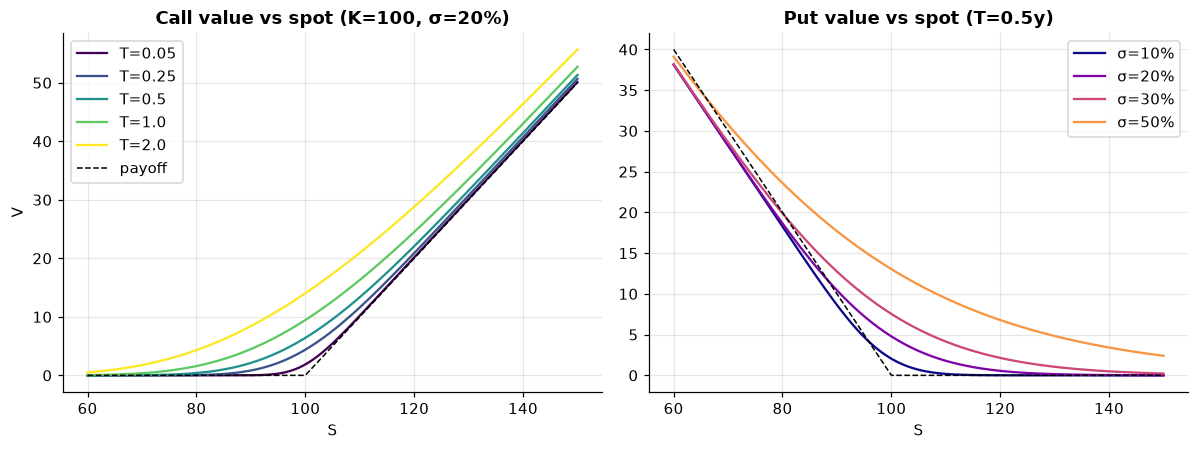

In [3]:
K, T, vol = 105, 0.5, 0.22
c, p = bs_price(S, K, T, r, q, vol, 1), bs_price(S, K, T, r, q, vol, -1)
print(f"Call {c:.4f}  Put {p:.4f}  parity error {c - p - (S*np.exp(-q*T) - K*np.exp(-r*T)):.1e}")
print(f"Implied-vol round trip: {implied_vol(c, S, K, T, r, q):.6f}")

Ss = np.linspace(60, 150, 300)
fig, ax = plt.subplots(1, 2)
for i, TT in enumerate([0.05, 0.25, 0.5, 1.0, 2.0]):
    ax[0].plot(Ss, bs_price(Ss, 100, TT, r, q, 0.2), color=cm.viridis(i/4), label=f"T={TT}")
ax[0].plot(Ss, np.maximum(Ss - 100, 0), "k--", lw=1, label="payoff")
ax[0].set(title="Call value vs spot (K=100, σ=20%)", xlabel="S", ylabel="V"); ax[0].legend()

for i, v in enumerate([0.1, 0.2, 0.3, 0.5]):
    ax[1].plot(Ss, bs_price(Ss, 100, 0.5, r, q, v, -1), color=cm.plasma(i/4), label=f"σ={v:.0%}")
ax[1].plot(Ss, np.maximum(100 - Ss, 0), "k--", lw=1)
ax[1].set(title="Put value vs spot (T=0.5y)", xlabel="S"); ax[1].legend()
plt.tight_layout()

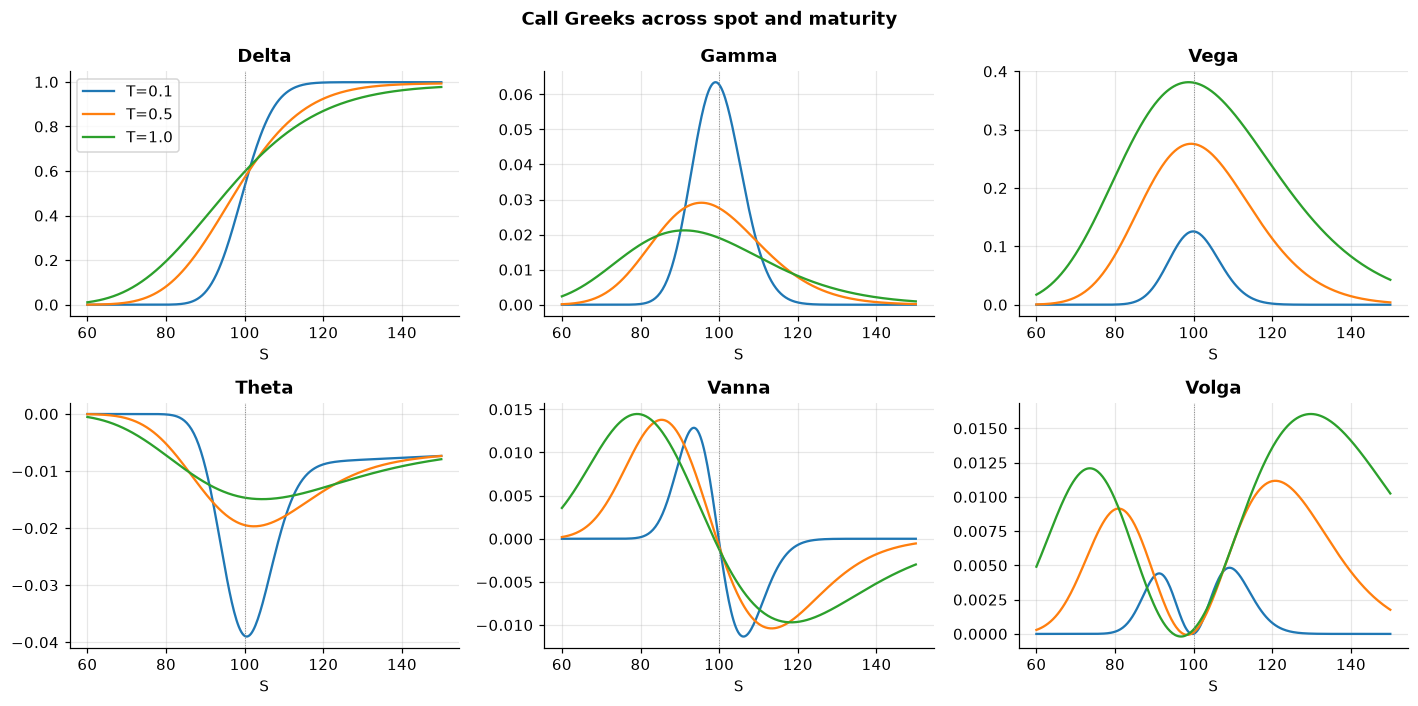

In [4]:
names = ["delta", "gamma", "vega", "theta", "vanna", "volga"]
fig, axes = plt.subplots(2, 3, figsize=(13, 6.5))
for ax, g in zip(axes.ravel(), names):
    for i, TT in enumerate([0.1, 0.5, 1.0]):
        ax.plot(Ss, bs_greeks(Ss, 100, TT, r, q, 0.2)[g], color=C[i], label=f"T={TT}")
    ax.axvline(100, color="grey", lw=0.6, ls=":")
    ax.set_title(g.capitalize()); ax.set_xlabel("S")
axes[0, 0].legend()
fig.suptitle("Call Greeks across spot and maturity", fontweight="bold")
plt.tight_layout()

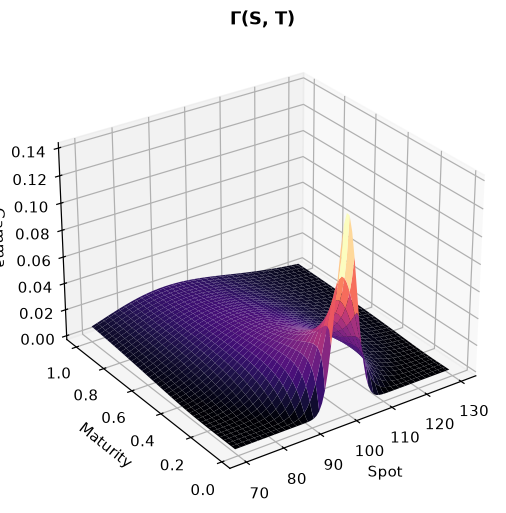

In [5]:
# Gamma surface: explodes near the strike as T → 0 (pin risk)
SS, TT = np.meshgrid(np.linspace(70, 130, 80), np.linspace(0.02, 1.0, 80))
G = bs_greeks(SS, 100, TT, r, q, 0.2)["gamma"]
fig = plt.figure(figsize=(9, 5.5)); ax = fig.add_subplot(projection="3d")
ax.plot_surface(SS, TT, G, cmap="magma", linewidth=0, antialiased=True)
ax.set(title="Γ(S, T)", xlabel="Spot", ylabel="Maturity", zlabel="Gamma"); ax.view_init(28, -125)

## 2 · Heston stochastic volatility

Constant $\sigma$ can't produce a skew. Heston lets the **variance** mean-revert and correlate with spot:

$$
\begin{aligned}
dS_t &= (r-q)S_t\,dt + \sqrt{v_t}\,S_t\,dW^S_t \\
dv_t &= \kappa(\theta - v_t)\,dt + \xi\sqrt{v_t}\,dW^v_t, \qquad d\langle W^S, W^v\rangle_t = \rho\,dt
\end{aligned}
$$

* $\kappa$ — speed of mean reversion, $\theta$ — long-run variance, $\xi$ — vol-of-vol, $\rho<0$ — leverage effect (equity skew).
* **Feller condition** $2\kappa\theta \ge \xi^2$ keeps $v_t>0$. Equity calibrations almost always violate it.

The characteristic function of $x_T=\ln S_T$ is affine in $v_0$ (Albrecher "little-trap" form):

$$
\varphi(u) = \exp\!\Big(C(u,T) + D(u,T)\,v_0 + iu\,[\ln S_0 + (r-q)T]\Big),
$$
$$
d=\sqrt{(\rho\xi iu-\kappa)^2+\xi^2(iu+u^2)},\quad g=\frac{\kappa-\rho\xi iu-d}{\kappa-\rho\xi iu+d},
$$
$$
C=\frac{\kappa\theta}{\xi^2}\Big[(\kappa-\rho\xi iu-d)T-2\ln\frac{1-ge^{-dT}}{1-g}\Big],\quad
D=\frac{\kappa-\rho\xi iu-d}{\xi^2}\cdot\frac{1-e^{-dT}}{1-ge^{-dT}}.
$$

Prices follow by Fourier inversion (Gil-Pelaez):

$$
C = S e^{-qT}P_1 - Ke^{-rT}P_2,\qquad
P_j = \tfrac12 + \frac1\pi\int_0^\infty \mathrm{Re}\!\left[\frac{e^{-iu\ln K}\,\varphi_j(u)}{iu}\right]du,
$$

with $\varphi_2=\varphi(u)$ and $\varphi_1=\varphi(u-i)/\varphi(-i)$ (share measure).

Empirical corr(dlnS, dσ) = -0.588  (ρ = -0.7)


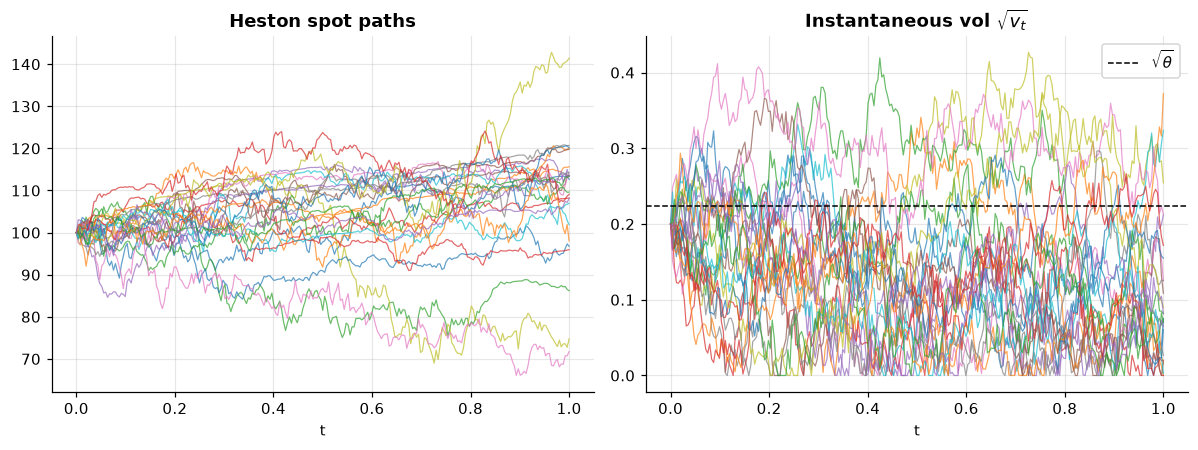

In [6]:
P, V = heston_paths_qe(S, 1.0, r, q, true, n_paths=2000, n_steps=252, return_var=True)
t = np.linspace(0, 1, 253)
fig, ax = plt.subplots(1, 2)
for i in range(25):
    ax[0].plot(t, P[i], lw=0.8, alpha=0.7); ax[1].plot(t, np.sqrt(V[i]), lw=0.8, alpha=0.7)
ax[0].set(title="Heston spot paths", xlabel="t"); ax[1].set(title=r"Instantaneous vol $\sqrt{v_t}$", xlabel="t")
ax[1].axhline(np.sqrt(true.theta), color="k", ls="--", lw=1, label=r"$\sqrt{\theta}$"); ax[1].legend()
plt.tight_layout()

# leverage effect: spot returns vs vol changes
dS = np.diff(np.log(P[:, ::5]), axis=1).ravel(); dv = np.diff(np.sqrt(V[:, ::5]), axis=1).ravel()
print(f"Empirical corr(dlnS, dσ) = {np.corrcoef(dS, dv)[0,1]:+.3f}  (ρ = {true.rho})")

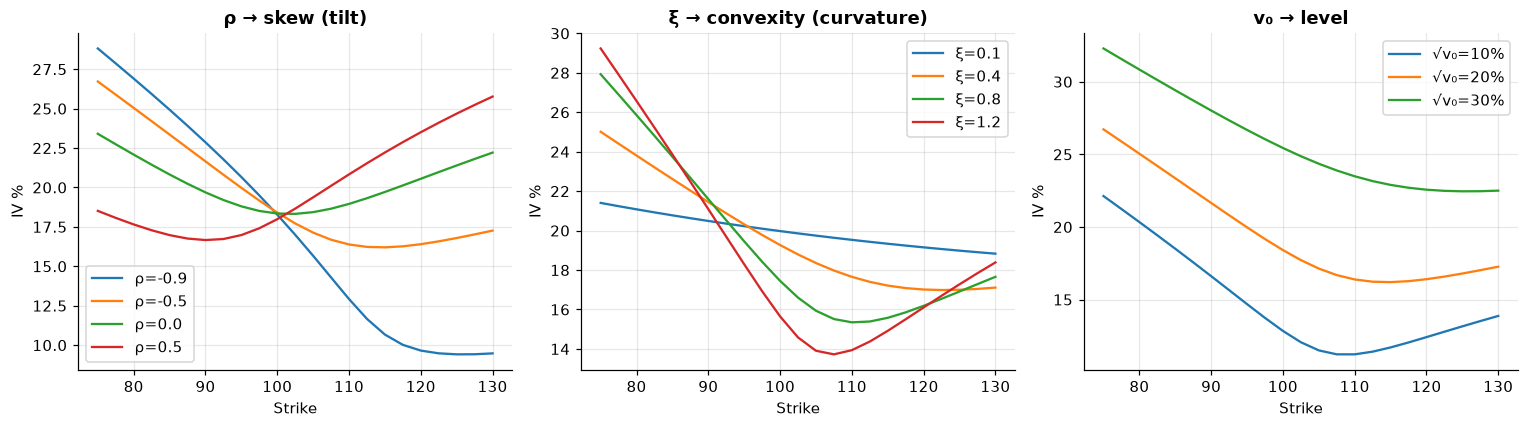

In [7]:
# How each parameter shapes the smile
Ks = np.linspace(75, 130, 23)
def smile(p, T=0.5):
    return [implied_vol(heston_price(S, K, T, r, q, p, 1 if K >= S else -1), S, K, T, r, q,
                        1 if K >= S else -1) for K in Ks]

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
for i, rho in enumerate([-0.9, -0.5, 0.0, 0.5]):
    ax[0].plot(Ks, 100*np.array(smile(HestonParams(0.04, 1.8, 0.04, 0.6, rho))), color=C[i], label=f"ρ={rho}")
for i, xi in enumerate([0.1, 0.4, 0.8, 1.2]):
    ax[1].plot(Ks, 100*np.array(smile(HestonParams(0.04, 1.8, 0.04, xi, -0.5))), color=C[i], label=f"ξ={xi}")
for i, v0 in enumerate([0.01, 0.04, 0.09]):
    ax[2].plot(Ks, 100*np.array(smile(HestonParams(v0, 1.8, 0.04, 0.6, -0.5))), color=C[i], label=f"√v₀={np.sqrt(v0):.0%}")
for a, t_ in zip(ax, ["ρ → skew (tilt)", "ξ → convexity (curvature)", "v₀ → level"]):
    a.set(title=t_, xlabel="Strike", ylabel="IV %"); a.legend()
plt.tight_layout()

## 3 · Andersen Quadratic-Exponential (QE) simulation

Plain Euler, $v_{t+\Delta}=v_t+\kappa(\theta-v_t^+)\Delta+\xi\sqrt{v_t^+\Delta}\,Z$, goes negative and must be truncated — biased when Feller fails.

QE instead matches the first two **exact** conditional moments of $v_{t+\Delta}$ (non-central $\chi^2$):

$$
m = \theta + (v_t-\theta)e^{-\kappa\Delta},\qquad
s^2 = \frac{v_t\xi^2e^{-\kappa\Delta}}{\kappa}(1-e^{-\kappa\Delta}) + \frac{\theta\xi^2}{2\kappa}(1-e^{-\kappa\Delta})^2,\qquad
\psi = s^2/m^2
$$

* $\psi\le\psi_c$ (**quadratic**): $\;v_{t+\Delta}=a(b+Z)^2,\quad b^2=\tfrac2\psi-1+\sqrt{\tfrac2\psi}\sqrt{\tfrac2\psi-1},\quad a=\tfrac{m}{1+b^2}$
* $\psi>\psi_c$ (**exponential**, with an atom at 0): $\;v_{t+\Delta}=\begin{cases}0 & U\le p\\ \beta^{-1}\ln\frac{1-p}{1-U} & U>p\end{cases},\quad p=\frac{\psi-1}{\psi+1},\ \beta=\frac{1-p}{m}$

Log-spot is then advanced with the integrated-variance scheme plus a **martingale correction** $K_0^*$ so that $\mathbb{E}[S_T]=F_T$ exactly:

$$
\ln S_{t+\Delta} = \ln S_t + (r-q)\Delta + K_0^* + K_1 v_t + K_2 v_{t+\Delta} + \sqrt{K_3 v_t + K_4 v_{t+\Delta}}\;Z.
$$

Feller 2κθ − ξ² = -0.96  (strongly violated)


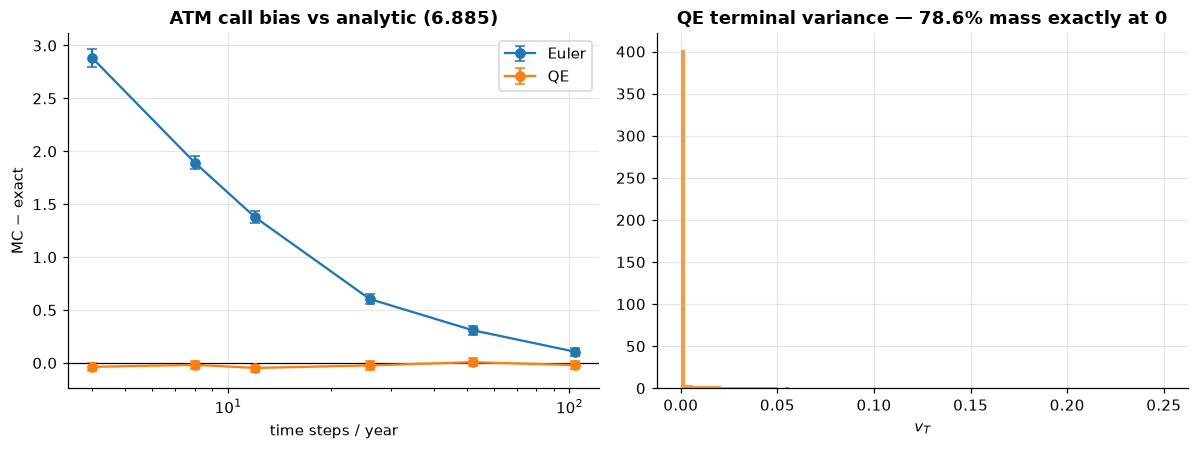

In [8]:
hard = HestonParams(v0=0.04, kappa=0.5, theta=0.04, xi=1.0, rho=-0.9)
print(f"Feller 2κθ − ξ² = {hard.feller():+.2f}  (strongly violated)")
ref = heston_price(S, 100, 1.0, r, q, hard)
steps = [4, 8, 12, 26, 52, 104]
bias = {"Euler": [], "QE": []}
for n in steps:
    for name, fn in (("Euler", heston_paths), ("QE", heston_paths_qe)):
        X = fn(S, 1.0, r, q, hard, n_paths=60_000, n_steps=n)
        px, se = mc_price(X, lambda Y: np.maximum(Y[:, -1] - 100, 0), r, 1.0)
        bias[name].append((px - ref, se))

fig, ax = plt.subplots(1, 2)
for i, (name, b) in enumerate(bias.items()):
    b = np.array(b)
    ax[0].errorbar(steps, b[:, 0], yerr=1.96*b[:, 1], marker="o", capsize=3, color=C[i], label=name)
ax[0].axhline(0, color="k", lw=0.8); ax[0].set_xscale("log")
ax[0].set(title=f"ATM call bias vs analytic ({ref:.3f})", xlabel="time steps / year", ylabel="MC − exact"); ax[0].legend()

_, Vq = heston_paths_qe(S, 1.0, r, q, hard, 50_000, 12, return_var=True)
ax[1].hist(Vq[:, -1], bins=120, range=(0, 0.25), color=C[1], alpha=0.8, density=True)
ax[1].set(title=f"QE terminal variance — {np.mean(Vq[:, -1] == 0):.1%} mass exactly at 0", xlabel=r"$v_T$")
plt.tight_layout()

## 4 · Calibrating Heston to an implied-vol surface

We minimise **vega-weighted** price errors, which to first order equal implied-vol errors:

$$
\hat\Theta = \arg\min_{\Theta}\ \sum_{i}\left(\frac{C^{\text{Heston}}_i(\Theta) - C^{\text{mkt}}_i}{\mathcal{V}_i}\right)^2
\;+\;\lambda\,\big(\xi^2 - 2\kappa\theta\big)_+^2,
\qquad \Theta=(v_0,\kappa,\theta,\xi,\rho)
$$

using OTM options only, since $\frac{C-C^{\text{mkt}}}{\mathcal V}\approx\sigma^{\text{model}}-\sigma^{\text{mkt}}$.

true       HestonParams(v0=0.04, kappa=1.8, theta=0.05, xi=0.6, rho=-0.7)
calibrated HestonParams(v0=np.float64(0.03996949266628695), kappa=np.float64(2.4373719057255085), theta=np.float64(0.04551045122826707), xi=np.float64(0.48709355796893133), rho=np.float64(-0.8162961042463129))
RMSE 0.550 vol pts


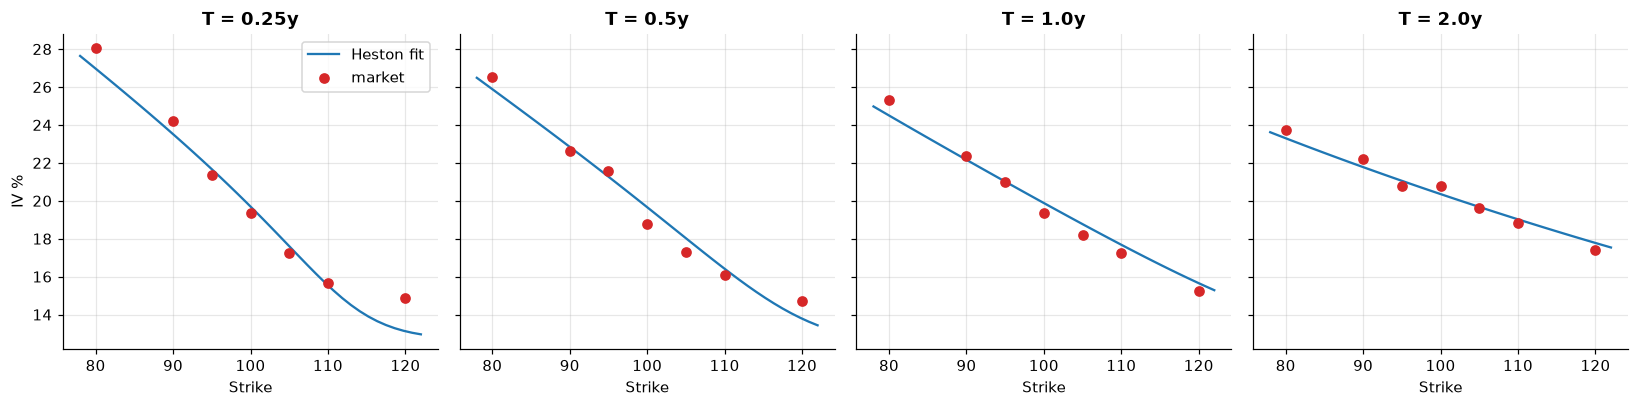

In [9]:
strikes = np.array([80, 90, 95, 100, 105, 110, 120.]); mats = np.array([0.25, 0.5, 1.0, 2.0])
cp_ = lambda K: 1 if K >= S else -1
surf_true = np.array([[implied_vol(heston_price(S, K, T, r, q, true, cp_(K)), S, K, T, r, q, cp_(K))
                       for K in strikes] for T in mats])
mkt = surf_true + qm.RNG.normal(0, 0.002, surf_true.shape)
fit, rmse = calibrate_heston(S, r, q, strikes, mats, mkt)
print("true      ", true); print("calibrated", fit); print(f"RMSE {100*rmse:.3f} vol pts")

Kf = np.linspace(78, 122, 40)
fig, axes = plt.subplots(1, 4, figsize=(15, 3.8), sharey=True)
for ax, T, row in zip(axes, mats, mkt):
    model = [implied_vol(heston_price(S, K, T, r, q, fit, cp_(K)), S, K, T, r, q, cp_(K)) for K in Kf]
    ax.plot(Kf, 100*np.array(model), color=C[0], label="Heston fit")
    ax.scatter(strikes, 100*row, color=C[3], zorder=3, label="market")
    ax.set(title=f"T = {T}y", xlabel="Strike")
axes[0].set_ylabel("IV %"); axes[0].legend(); plt.tight_layout()

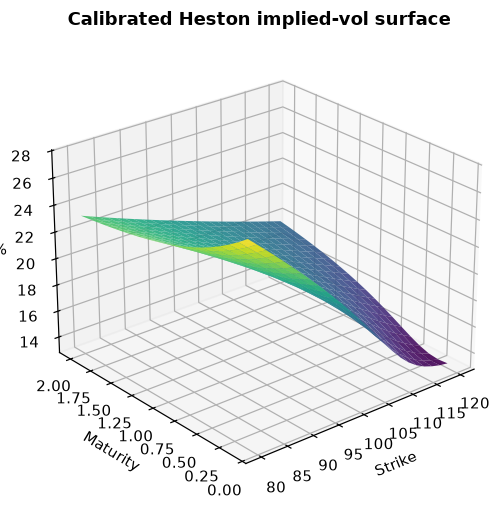

In [10]:
KK, TT = np.meshgrid(np.linspace(80, 120, 25), np.linspace(0.1, 2.0, 20))
IV = np.vectorize(lambda K, T: implied_vol(heston_price(S, K, T, r, q, fit, cp_(K)), S, K, T, r, q, cp_(K)))(KK, TT)
fig = plt.figure(figsize=(9, 5.5)); ax = fig.add_subplot(projection="3d")
ax.plot_surface(KK, TT, 100*IV, cmap="viridis", alpha=0.9)
ax.set(title="Calibrated Heston implied-vol surface", xlabel="Strike", ylabel="Maturity", zlabel="IV %")
ax.view_init(25, -130)

## 5 · Monte Carlo for path-dependent payoffs

$$
V_0 = e^{-rT}\,\mathbb{E}^{\mathbb{Q}}[\,h(S_{t_1},\dots,S_{t_n})\,] \approx \frac{e^{-rT}}{N}\sum_{j=1}^N h\big(S^{(j)}\big),\qquad
\text{s.e.} = \frac{\hat\sigma_h}{\sqrt N}
$$

| Payoff | $h$ |
|---|---|
| Arithmetic Asian call | $\big(\tfrac1n\sum_i S_{t_i} - K\big)^+$ |
| Down-and-out call | $(S_T-K)^+\,\mathbf 1\{\min_t S_t > B\}$ |

**Variance reduction.** *Antithetics* reuse $-Z$. A *control variate* $Y$ with known mean gives

$$
\hat V_{\text{CV}} = \bar X - \beta^*(\bar Y - \mathbb{E}Y),\qquad \beta^* = \frac{\mathrm{Cov}(X,Y)}{\mathrm{Var}(Y)},\qquad
\mathrm{Var}(\hat V_{\text{CV}}) = (1-\rho_{XY}^2)\,\mathrm{Var}(\bar X).
$$

Here $Y=e^{-rT}S_T$ with $\mathbb{E}Y=S_0e^{-qT}$.

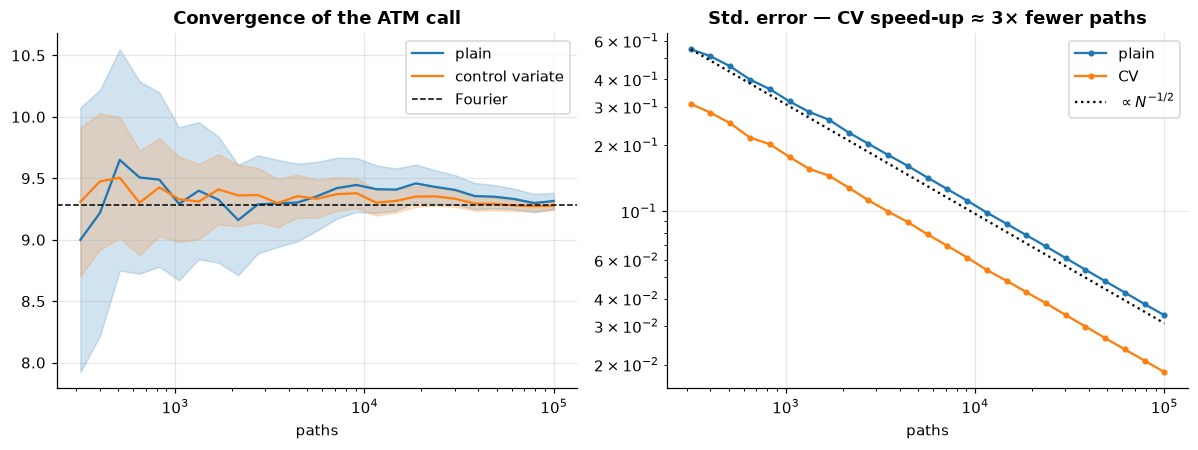

In [11]:
ref = heston_price(S, 100, 1.0, r, q, true)
X = heston_paths_qe(S, 1.0, r, q, true, n_paths=100_000, n_steps=100)
Ns = np.unique(np.logspace(2.5, 5, 25).astype(int))
plain, cv = [], []
for n in Ns:
    plain.append(mc_price(X[:n], lambda Y: np.maximum(Y[:, -1] - 100, 0), r, 1.0))
    cv.append(mc_price(X[:n], lambda Y: np.maximum(Y[:, -1] - 100, 0), r, 1.0,
                       control=lambda Y: Y[:, -1], control_mean=S*np.exp(-q)))
plain, cv = np.array(plain), np.array(cv)

fig, ax = plt.subplots(1, 2)
for i, (lab, a) in enumerate([("plain", plain), ("control variate", cv)]):
    ax[0].plot(Ns, a[:, 0], color=C[i], label=lab)
    ax[0].fill_between(Ns, a[:, 0] - 1.96*a[:, 1], a[:, 0] + 1.96*a[:, 1], color=C[i], alpha=0.2)
ax[0].axhline(ref, color="k", ls="--", lw=1, label="Fourier"); ax[0].set_xscale("log")
ax[0].set(title="Convergence of the ATM call", xlabel="paths"); ax[0].legend()
ax[1].loglog(Ns, plain[:, 1], "o-", ms=3, label="plain"); ax[1].loglog(Ns, cv[:, 1], "o-", ms=3, label="CV")
ax[1].loglog(Ns, plain[0, 1]*np.sqrt(Ns[0]/Ns), "k:", label=r"$\propto N^{-1/2}$")
ax[1].set(title=f"Std. error — CV speed-up ≈ {(plain[-1,1]/cv[-1,1])**2:.0f}× fewer paths", xlabel="paths"); ax[1].legend()
plt.tight_layout()

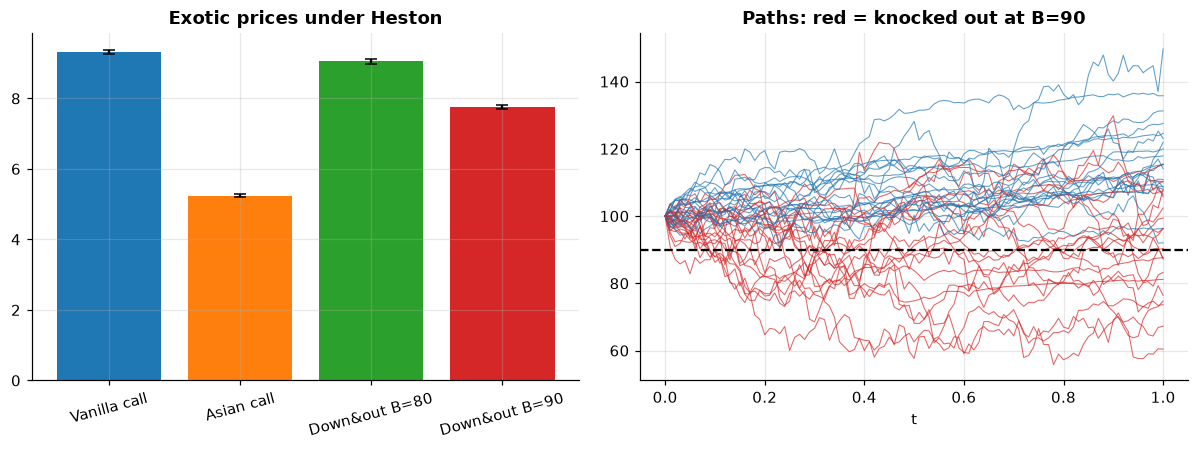

In [12]:
payoffs = {"Vanilla call": lambda Y: np.maximum(Y[:, -1] - 100, 0),
           "Asian call":   lambda Y: np.maximum(Y[:, 1:].mean(1) - 100, 0),
           "Down&out B=80": lambda Y: np.where(Y.min(1) > 80, np.maximum(Y[:, -1] - 100, 0), 0),
           "Down&out B=90": lambda Y: np.where(Y.min(1) > 90, np.maximum(Y[:, -1] - 100, 0), 0)}
vals = {k: mc_price(X, f, r, 1.0) for k, f in payoffs.items()}

fig, ax = plt.subplots(1, 2)
ax[0].bar(vals.keys(), [v[0] for v in vals.values()], yerr=[1.96*v[1] for v in vals.values()],
          color=C[:4], capsize=4)
ax[0].set(title="Exotic prices under Heston"); ax[0].tick_params(axis="x", rotation=15)
for i in range(40):
    ko = X[i].min() <= 90
    ax[1].plot(np.linspace(0, 1, X.shape[1]), X[i], color=C[3] if ko else C[0], lw=0.7, alpha=0.7)
ax[1].axhline(90, color="k", ls="--"); ax[1].set(title="Paths: red = knocked out at B=90", xlabel="t")
plt.tight_layout()

## 6 · Delta hedging and the P&L of volatility

A short option, delta-hedged at implied vol $\sigma_{\text{imp}}$ while the stock realises $\sigma_{\text{real}}$, accrues

$$
d\Pi_t = \tfrac12\,\Gamma_t S_t^2\left(\sigma_{\text{imp}}^2 - \sigma_{\text{real}}^2\right)dt
\quad\Longrightarrow\quad
\Pi_T = \tfrac12\int_0^T e^{r(T-t)}\,\Gamma_t S_t^2\left(\sigma_{\text{imp}}^2 - \sigma_{\text{real},t}^2\right)dt.
$$

Theta pays for gamma. You're **short gamma, long theta**, so you make money iff realised < implied — weighted by *dollar gamma* $\Gamma S^2$, which makes the P&L path-dependent.

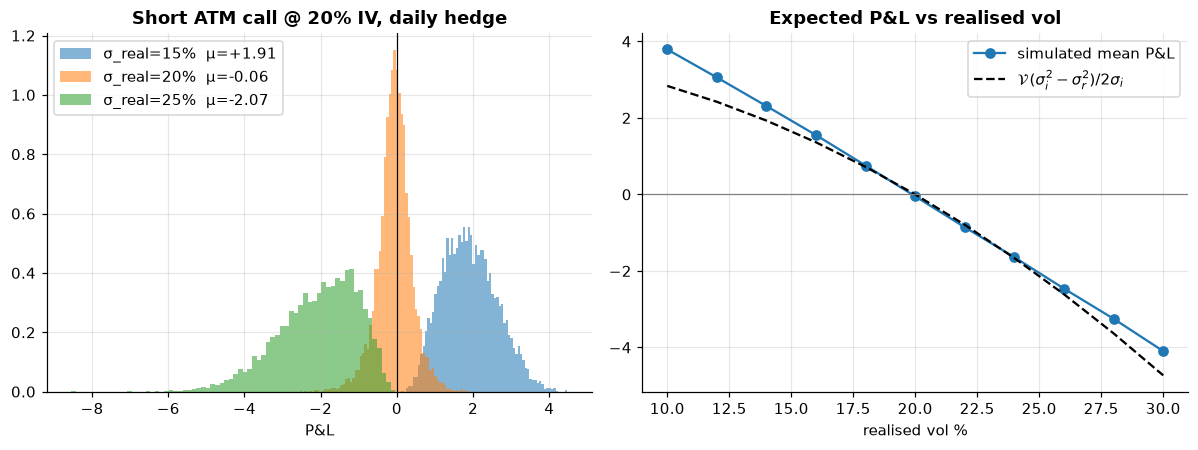

In [13]:
fig, ax = plt.subplots(1, 2)
res = {}
for i, rv in enumerate([0.15, 0.20, 0.25]):
    pnl = delta_hedge_pnl(S, 100, 1.0, r, 0.20, rv, n_paths=6000)
    res[rv] = pnl
    ax[0].hist(pnl, bins=70, alpha=0.55, color=C[i], density=True, label=f"σ_real={rv:.0%}  μ={pnl.mean():+.2f}")
ax[0].axvline(0, color="k", lw=0.8); ax[0].set(title="Short ATM call @ 20% IV, daily hedge", xlabel="P&L"); ax[0].legend()

rvs = np.linspace(0.10, 0.30, 11)
means = [delta_hedge_pnl(S, 100, 1.0, r, 0.20, rv, n_paths=1500).mean() for rv in rvs]
vega = bs_greeks(S, 100, 1.0, r, 0, 0.20)["vega"] * 100
ax[1].plot(100*rvs, means, "o-", label="simulated mean P&L")
ax[1].plot(100*rvs, vega*(0.20**2 - rvs**2)/(2*0.20), "k--", label=r"$\mathcal{V}\,(\sigma_i^2-\sigma_r^2)/2\sigma_i$")
ax[1].axhline(0, color="grey", lw=0.8)
ax[1].set(title="Expected P&L vs realised vol", xlabel="realised vol %"); ax[1].legend()
plt.tight_layout()

## 7 · Portfolio risk: VaR and Expected Shortfall

For P&L $L$ over horizon $h$ at confidence $\alpha$:

$$
\mathrm{VaR}_\alpha = -\inf\{\ell : \mathbb{P}(L\le \ell) > 1-\alpha\},\qquad
\mathrm{ES}_\alpha = -\mathbb{E}\left[L \mid L \le -\mathrm{VaR}_\alpha\right].
$$

ES is **coherent** (sub-additive) and is the Basel FRTB standard. Option books are non-linear, so we use **full revaluation** under correlated spot/vol shocks:

$$
S_h = S_0\,e^{-\frac12\sigma^2h + \sigma\sqrt h\,Z_1},\qquad
\Delta\sigma_{\text{imp}} = \nu\,\sigma\sqrt h\,\big(\rho Z_1 + \sqrt{1-\rho^2}Z_2\big)
$$

versus the **delta-gamma** approximation $\;L \approx \Delta\,\delta S + \tfrac12\Gamma\,\delta S^2 + \mathcal V\,\delta\sigma + \Theta\,h$.

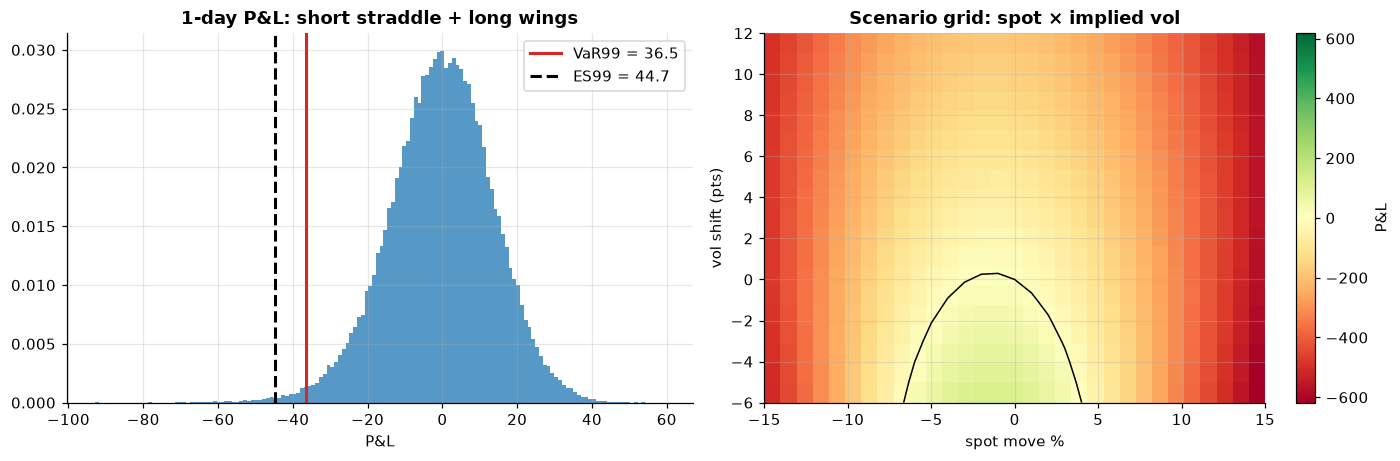

In [14]:
book = [Position(-100, 100, 0.25, 1, 0.20), Position(-100, 100, 0.25, -1, 0.20),
        Position(50, 90, 0.5, -1, 0.26), Position(50, 110, 0.5, 1, 0.17)]
var, es, pnl = var_es(book, S, r, q, horizon_days=1)
V0 = portfolio_value(book, S, r, q)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.3))
ax[0].hist(pnl, bins=150, color=C[0], alpha=0.75, density=True)
ax[0].axvline(-var, color=C[3], lw=2, label=f"VaR99 = {var:.1f}")
ax[0].axvline(-es, color="k", lw=2, ls="--", label=f"ES99 = {es:.1f}")
ax[0].set(title="1-day P&L: short straddle + long wings", xlabel="P&L"); ax[0].legend()

sh = np.linspace(-0.15, 0.15, 31); dvs = np.linspace(-0.06, 0.12, 19)
grid = np.array([[portfolio_value(book, S*(1+s), r, q, dv) - V0 for s in sh] for dv in dvs])
im = ax[1].imshow(grid, origin="lower", aspect="auto", cmap="RdYlGn",
                  extent=[100*sh[0], 100*sh[-1], 100*dvs[0], 100*dvs[-1]],
                  vmin=-np.abs(grid).max(), vmax=np.abs(grid).max())
ax[1].contour(100*sh, 100*dvs, grid, levels=[0], colors="k", linewidths=1)
plt.colorbar(im, ax=ax[1], label="P&L")
ax[1].set(title="Scenario grid: spot × implied vol", xlabel="spot move %", ylabel="vol shift (pts)")
plt.tight_layout()

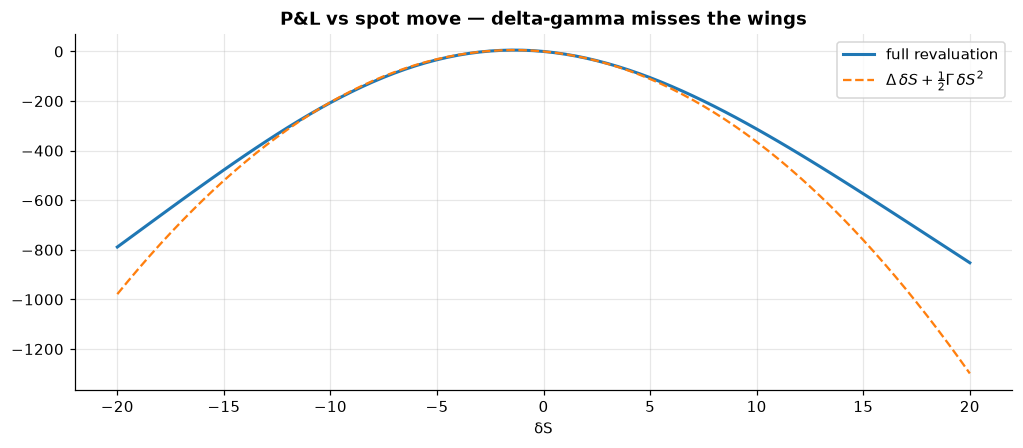

In [15]:
# Delta-gamma vs full revaluation — where Taylor breaks
agg = {k: sum(p_.qty*bs_greeks(S, p_.K, p_.T, r, q, p_.vol, p_.cp)[k] for p_ in book) for k in ("delta", "gamma")}
moves = np.linspace(-20, 20, 81)
full = [portfolio_value(book, S+m, r, q) - V0 for m in moves]
taylor = agg["delta"]*moves + 0.5*agg["gamma"]*moves**2
plt.plot(moves, full, label="full revaluation", lw=2); plt.plot(moves, taylor, "--", label=r"$\Delta\,\delta S + \frac{1}{2}\Gamma\,\delta S^2$")
plt.title("P&L vs spot move — delta-gamma misses the wings"); plt.xlabel("δS"); plt.legend();

## 8 · Statistical arbitrage: Ornstein–Uhlenbeck pairs

For cointegrated $\ln Y_t = \alpha + \beta\ln X_t + s_t$, the spread is modelled as OU:

$$
ds_t = \kappa(\mu - s_t)\,dt + \sigma\,dW_t,\qquad
s_{t+\Delta} = \mu(1-e^{-\kappa\Delta}) + e^{-\kappa\Delta}s_t + \varepsilon_t
$$

An AR(1) regression $s_{t+1}=a\,s_t+b+\varepsilon$ recovers

$$
\kappa = -\frac{\ln a}{\Delta},\qquad \mu=\frac{b}{1-a},\qquad \sigma_{\text{eq}}=\frac{\sigma_\varepsilon}{\sqrt{1-a^2}},\qquad t_{1/2}=\frac{\ln 2}{\kappa}.
$$

Trade the z-score $z_t=(s_t-\mu)/\sigma_{\text{eq}}$: enter at $|z|>2$, exit at $|z|<0.5$, with $\beta$ re-estimated monthly on a rolling window (no look-ahead) and 2 bp costs per side.

OU: κ=8.26, half-life=21.1d | ann_ret=0.045, ann_vol=0.036, sharpe=1.268, max_dd=0.040, trades=48, hit_rate=0.541


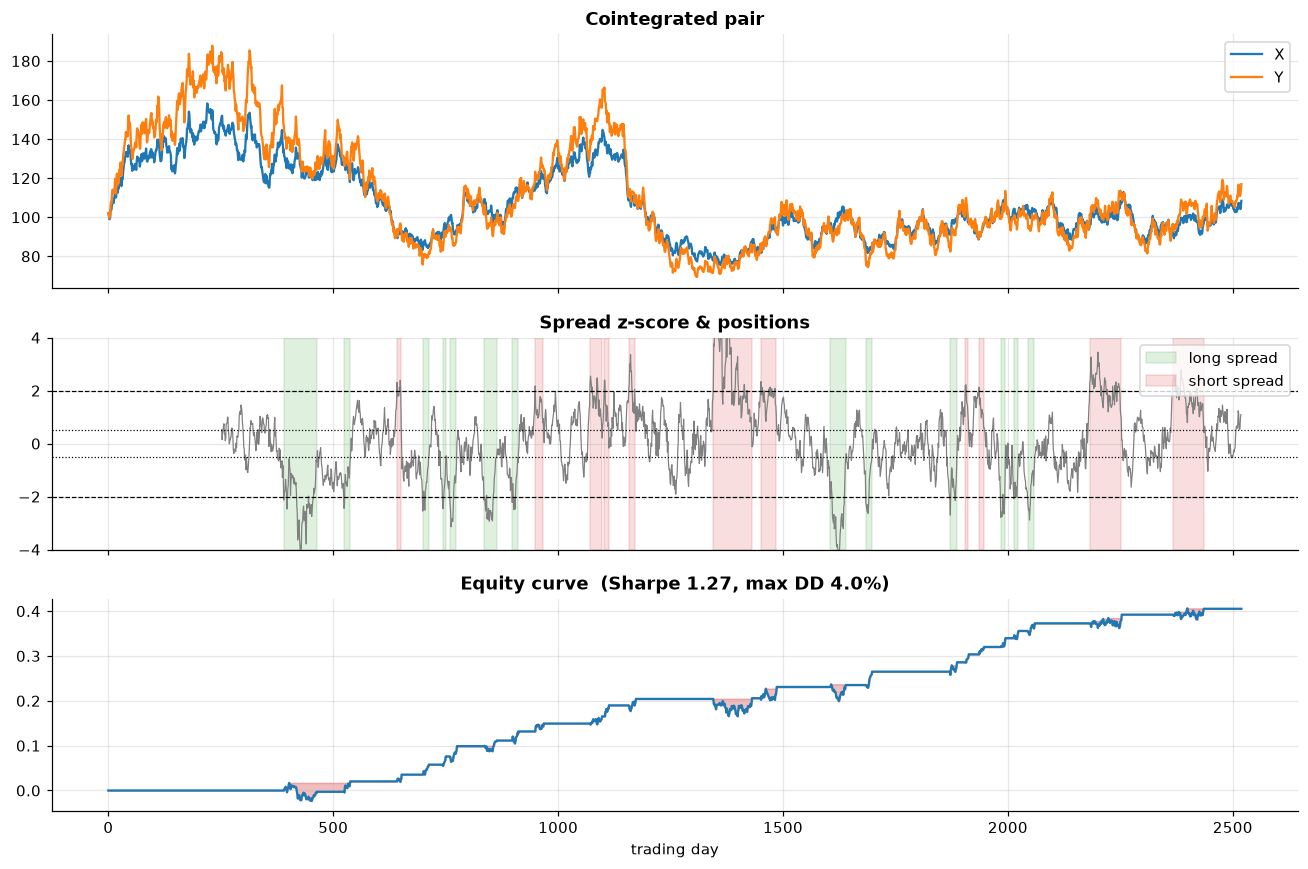

In [16]:
x, y = simulate_pair()
k_, mu_, sd_, hl = fit_ou(np.log(y) - 1.3*np.log(x))
stats, ser = pairs_backtest(x, y, return_series=True)
print(f"OU: κ={k_:.2f}, half-life={hl:.1f}d | " + ", ".join(f"{k}={v:.3f}" if isinstance(v, float) else f"{k}={v}" for k, v in stats.items()))

fig, ax = plt.subplots(3, 1, figsize=(12, 8), sharex=True, gridspec_kw={"height_ratios": [1.2, 1, 1]})
ax[0].plot(x, label="X"); ax[0].plot(y, label="Y"); ax[0].set_title("Cointegrated pair"); ax[0].legend()
ax[1].plot(ser["z"], color="grey", lw=0.8)
for lvl, st in [(2, "--"), (-2, "--"), (0.5, ":"), (-0.5, ":")]: ax[1].axhline(lvl, color="k", ls=st, lw=0.8)
ax[1].fill_between(range(len(x)), -4, 4, where=ser["pos"] > 0, color=C[2], alpha=0.15, label="long spread")
ax[1].fill_between(range(len(x)), -4, 4, where=ser["pos"] < 0, color=C[3], alpha=0.15, label="short spread")
ax[1].set(ylim=(-4, 4), title="Spread z-score & positions"); ax[1].legend(loc="upper right")
eq = ser["equity"]; ax[2].plot(eq, color=C[0]); ax[2].fill_between(range(len(eq)), eq, np.maximum.accumulate(eq), color=C[3], alpha=0.3)
ax[2].set(title=f"Equity curve  (Sharpe {stats['sharpe']:.2f}, max DD {stats['max_dd']:.1%})", xlabel="trading day")
plt.tight_layout()

## 9 · SVI: an arbitrage-free implied-vol surface

Gatheral's **raw SVI** parameterises total implied variance $w(k,T)=\sigma_{\text{BS}}^2(k,T)\,T$ in log-moneyness $k=\ln(K/F_T)$:

$$
w(k) = a + b\left[\rho\,(k-m) + \sqrt{(k-m)^2 + \sigma^2}\right]
$$

**No butterfly arbitrage** ⇔ the implied risk-neutral density is non-negative ⇔

$$
g(k) = \left(1 - \frac{k\,w'}{2w}\right)^2 - \frac{w'^2}{4}\left(\frac1w + \frac14\right) + \frac{w''}{2} \;\ge\; 0,
\qquad p(k) = \frac{g(k)}{\sqrt{2\pi w}}\exp\!\left(-\frac{d_2^2}{2}\right).
$$

**No calendar arbitrage** ⇔ $\partial_T w(k,T)\ge0$: total-variance slices never cross. Roger Lee's moment formula bounds the wings: $b(1+|\rho|)\le 4/T$.

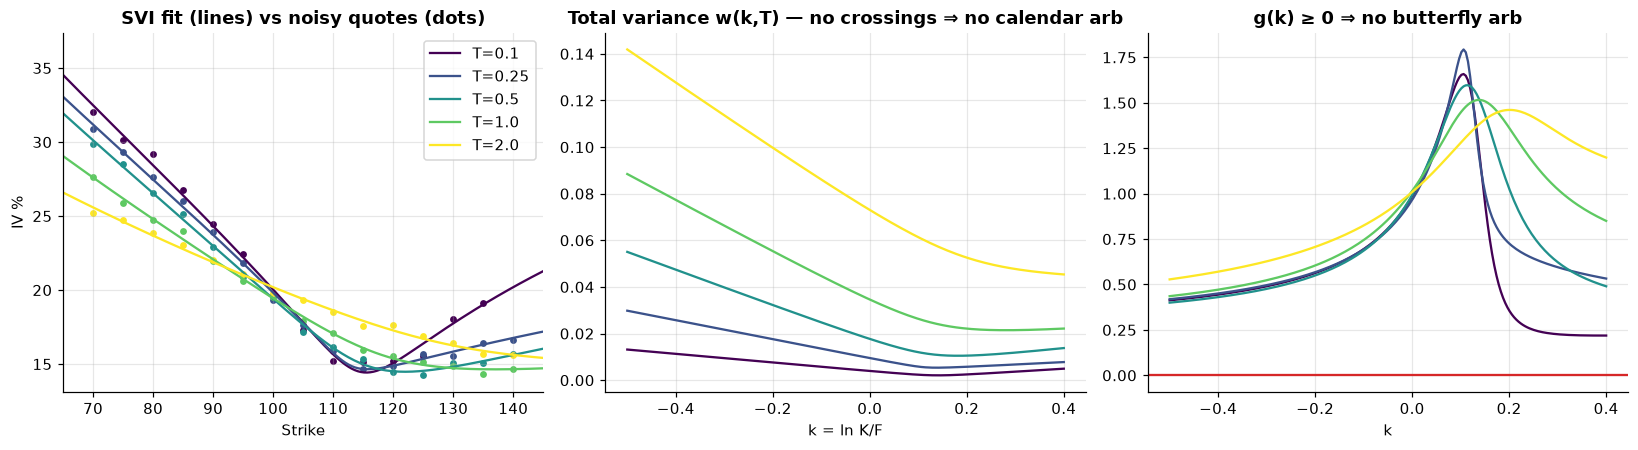

In [17]:
strikes9 = np.linspace(70, 140, 15); mats9 = np.array([0.1, 0.25, 0.5, 1.0, 2.0])
fwd = lambda T: S*np.exp((r-q)*T)
cpf = lambda K, T: 1 if K >= fwd(T) else -1
mkt9 = np.array([[implied_vol(heston_price(S, K, T, r, q, true, cpf(K, T)), S, K, T, r, q, cpf(K, T))
                  for K in strikes9] for T in mats9]) + qm.RNG.normal(0, 0.003, (5, 15))
svi = SVISurface(S, r, q, mats9, strikes9, mkt9)

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
kg = np.linspace(-0.5, 0.4, 200)
for i, (T, p_, row) in enumerate(zip(mats9, svi.params, mkt9)):
    col = cm.viridis(i/4)
    ax[0].plot(np.exp(kg)*fwd(T), 100*np.sqrt(svi_w(kg, *p_)/T), color=col, label=f"T={T}")
    ax[0].scatter(strikes9, 100*row, color=col, s=12)
    ax[1].plot(kg, svi_w(kg, *p_), color=col)
    ax[2].plot(kg, butterfly_g(kg, p_), color=col)
ax[0].set(title="SVI fit (lines) vs noisy quotes (dots)", xlabel="Strike", ylabel="IV %", xlim=(65, 145)); ax[0].legend()
ax[1].set(title="Total variance w(k,T) — no crossings ⇒ no calendar arb", xlabel="k = ln K/F")
ax[2].axhline(0, color=C[3]); ax[2].set(title="g(k) ≥ 0 ⇒ no butterfly arb", xlabel="k")
plt.tight_layout()

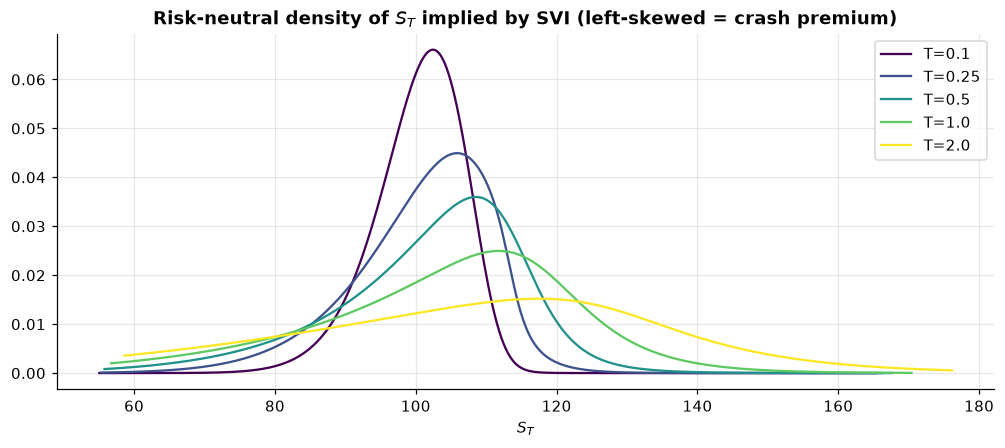

In [18]:
# Risk-neutral densities implied by each SVI slice
kg = np.linspace(-0.6, 0.5, 400)
for i, (T, p_) in enumerate(zip(mats9, svi.params)):
    w = svi_w(kg, *p_); d2 = -kg/np.sqrt(w) - np.sqrt(w)/2
    dens = butterfly_g(kg, p_)/np.sqrt(2*np.pi*w)*np.exp(-d2**2/2)
    plt.plot(np.exp(kg)*fwd(T), dens/(np.exp(kg)*fwd(T)), color=cm.viridis(i/4), label=f"T={T}")
plt.title("Risk-neutral density of $S_T$ implied by SVI (left-skewed = crash premium)"); plt.xlabel("$S_T$"); plt.legend();

## 10 · Dupire local volatility

The unique one-factor diffusion $dS_t=(r-q)S_t\,dt+\sigma_{\text{loc}}(t,S_t)S_t\,dW_t$ consistent with **all** vanilla prices is given by Dupire:

$$
\sigma_{\text{loc}}^2(K,T) = \frac{\dfrac{\partial C}{\partial T} + (r-q)K\dfrac{\partial C}{\partial K} + qC}{\tfrac12 K^2 \dfrac{\partial^2 C}{\partial K^2}}.
$$

In total-variance form (numerically much better behaved — Gatheral eq. 1.10):

$$
\sigma_{\text{loc}}^2(k,T) = \frac{\partial_T w}{1 - \dfrac{k}{w}\partial_k w + \dfrac14\left(-\dfrac14 - \dfrac1w + \dfrac{k^2}{w^2}\right)(\partial_k w)^2 + \dfrac12\partial_{kk} w}.
$$

Rule of thumb: local skew ≈ **2×** implied skew near the money, so local vol overshoots the smile.

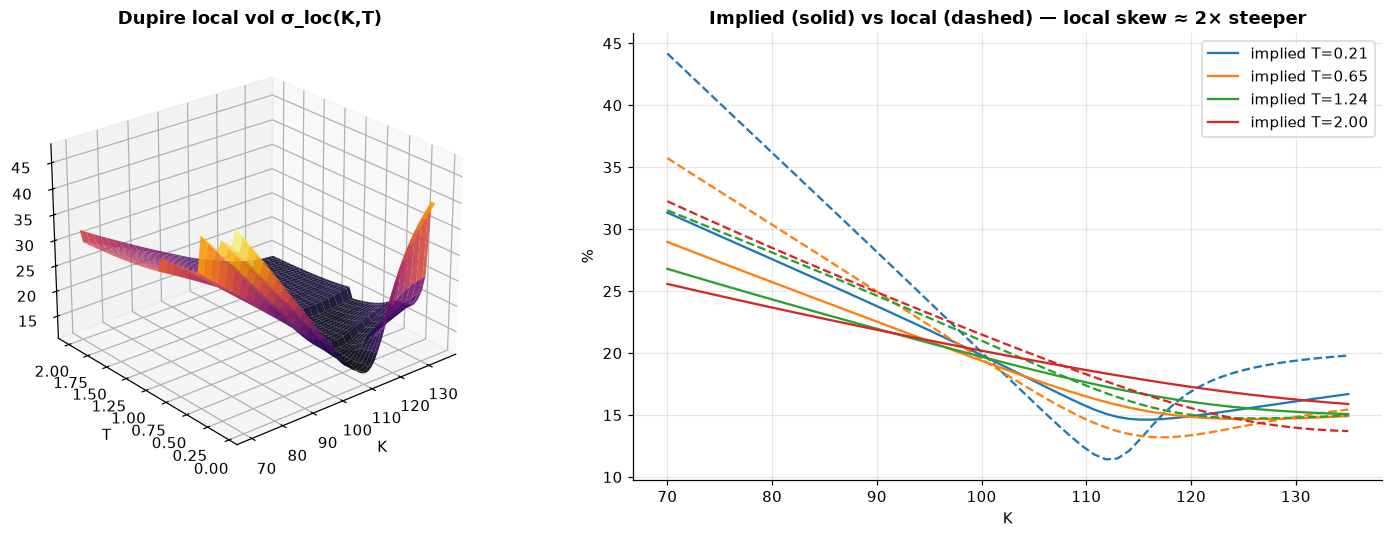

In [19]:
KK, TT = np.meshgrid(np.linspace(70, 135, 60), np.linspace(0.05, 2.0, 50))
LV = np.array([[svi.local_vol(K, T) for K in KK[0]] for T in TT[:, 0]])
IVs = np.array([[svi.iv(K, T) for K in KK[0]] for T in TT[:, 0]])

fig = plt.figure(figsize=(14, 5))
ax = fig.add_subplot(1, 2, 1, projection="3d")
ax.plot_surface(KK, TT, 100*LV, cmap="inferno", alpha=0.9)
ax.set(title="Dupire local vol σ_loc(K,T)", xlabel="K", ylabel="T", zlabel="%"); ax.view_init(25, -130)
ax = fig.add_subplot(1, 2, 2)
for i, j in enumerate([4, 15, 30, 49]):
    ax.plot(KK[0], 100*IVs[j], color=C[i], label=f"implied T={TT[j,0]:.2f}")
    ax.plot(KK[0], 100*LV[j], color=C[i], ls="--")
ax.set(title="Implied (solid) vs local (dashed) — local skew ≈ 2× steeper", xlabel="K", ylabel="%"); ax.legend()
plt.tight_layout()

## 11 · Heston stochastic-local volatility (SLV)

Local vol fits today's smile but predicts **flattening forward skew** — it misprices barriers and cliquets. Pure Heston has realistic dynamics but can't fit the whole surface. SLV combines them:

$$
dS_t = (r-q)S_t\,dt + L(t,S_t)\sqrt{v_t}\,S_t\,dW_t^S,\qquad dv_t=\kappa(\theta-v_t)dt+\xi\sqrt{v_t}\,dW_t^v.
$$

**Gyöngy's theorem** says SLV reprices every vanilla iff the *leverage function* satisfies

$$
L^2(t,K)\;\mathbb{E}^{\mathbb{Q}}\!\left[v_t \mid S_t = K\right] = \sigma_{\text{loc}}^2(t,K)
\quad\Longrightarrow\quad
L(t,K) = \frac{\sigma_{\text{loc}}(t,K)}{\sqrt{\mathbb{E}[v_t\mid S_t=K]}}.
$$

The conditional expectation is estimated on the fly from the simulated particles (Guyon & Henry-Labordère), here by quantile binning.

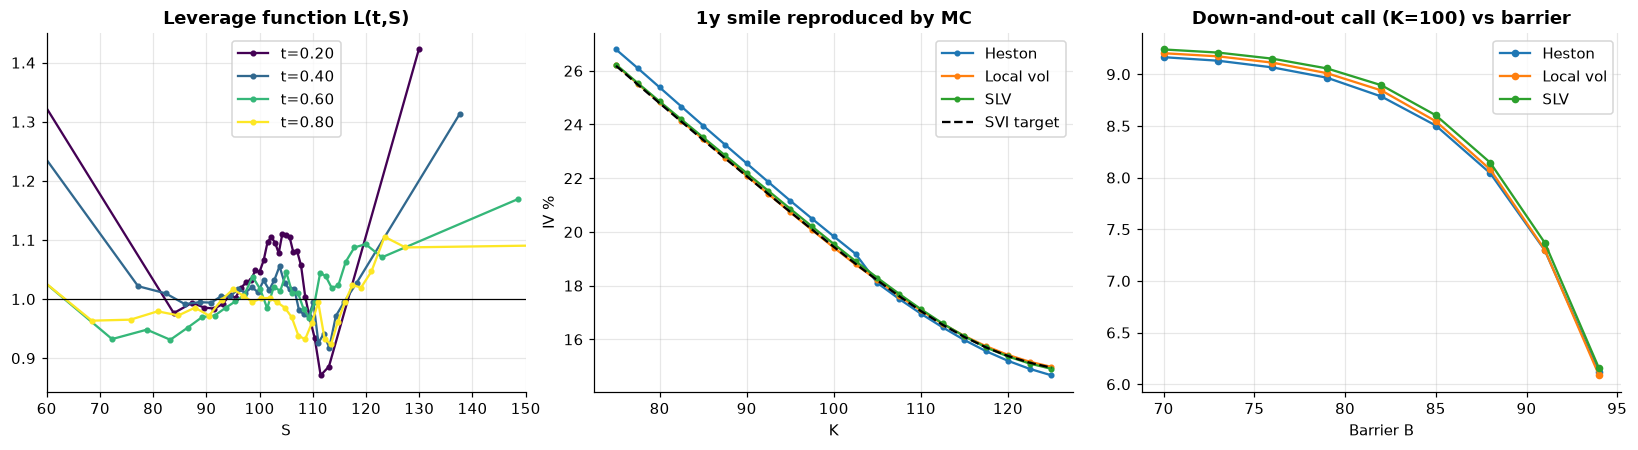

In [20]:
T1, B = 1.0, 85.0
Plv = lv_paths(S, T1, r, q, svi, 40_000, 150)
Pslv, lev = slv_paths(S, T1, r, q, svi, true, 40_000, 150, record_leverage=True)
Ph = heston_paths_qe(S, T1, r, q, true, 40_000, 150)

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
for i, (t_, (ctr, L)) in enumerate(lev.items()):
    ax[0].plot(ctr, L, "o-", ms=3, color=cm.viridis(i/max(len(lev)-1, 1)), label=f"t={t_:.2f}")
ax[0].axhline(1, color="k", lw=0.8); ax[0].set(title="Leverage function L(t,S)", xlabel="S", xlim=(60, 150)); ax[0].legend()

Ks_ = np.linspace(75, 125, 21)
for i, (name, P_) in enumerate([("Heston", Ph), ("Local vol", Plv), ("SLV", Pslv)]):
    ivs = [implied_vol(mc_price(P_, lambda X: np.maximum(cpf(K, T1)*(X[:, -1]-K), 0), r, T1)[0], S, K, T1, r, q, cpf(K, T1)) for K in Ks_]
    ax[1].plot(Ks_, 100*np.array(ivs), "o-", ms=3, color=C[i], label=name)
ax[1].plot(Ks_, 100*svi.iv(Ks_, T1), "k--", label="SVI target")
ax[1].set(title="1y smile reproduced by MC", xlabel="K", ylabel="IV %"); ax[1].legend()

barriers = np.arange(70, 97, 3)
for i, (name, P_) in enumerate([("Heston", Ph), ("Local vol", Plv), ("SLV", Pslv)]):
    ax[2].plot(barriers, [mc_price(P_, lambda X: np.where(X.min(1) > b, np.maximum(X[:, -1]-100, 0), 0), r, T1)[0]
                          for b in barriers], "o-", ms=4, color=C[i], label=name)
ax[2].set(title="Down-and-out call (K=100) vs barrier", xlabel="Barrier B"); ax[2].legend()
plt.tight_layout()

## 12 · Live market: the full stack on a real option chain

Data from Yahoo Finance (≈15 min delayed). For each expiry the **forward and discount factor are implied from put–call parity**, regressing across near-ATM strikes:

$$
C(K) - P(K) = D_T\,F_T - D_T\,K \quad\Longrightarrow\quad D_T = -\text{slope},\quad F_T = \frac{\text{intercept}}{D_T},\quad q_T = r - \frac{\ln(F_T/S)}{T}.
$$

Only OTM mid quotes with bid $>0$ and spread $<25\%$ are kept; IVs are recomputed with our own solver. Change `TICKER` to run any optionable name.

In [21]:
TICKER = "SPY"
try:
    from market_data import load_surface, to_grid
    from run_live import svi_from_quotes
    ms = load_surface(TICKER)
    LIVE = True
    print(f"{TICKER} spot {ms.spot:.2f} | r {ms.r:.3%} | implied carry {ms.q:.3%} | "
          f"{len(ms.quotes)} quotes, {ms.quotes['T'].nunique()} expiries | {ms.asof}")
except Exception as e:
    LIVE = False
    print("Live data unavailable (offline / market data error):", e)

SPY spot 762.78 | r 4.009% | implied carry 0.155% | 514 quotes, 6 expiries | 2026-09-29 17:15 UTC


  2026-10-06  n= 42  SVI RMSE 0.16 vol pts
  2026-10-16  n=137  SVI RMSE 0.22 vol pts
  2026-11-20  n= 95  SVI RMSE 0.07 vol pts
  2027-01-29  n=118  SVI RMSE 0.07 vol pts
  2027-06-17  n= 59  SVI RMSE 0.06 vol pts
  2028-01-21  n= 63  SVI RMSE 0.11 vol pts


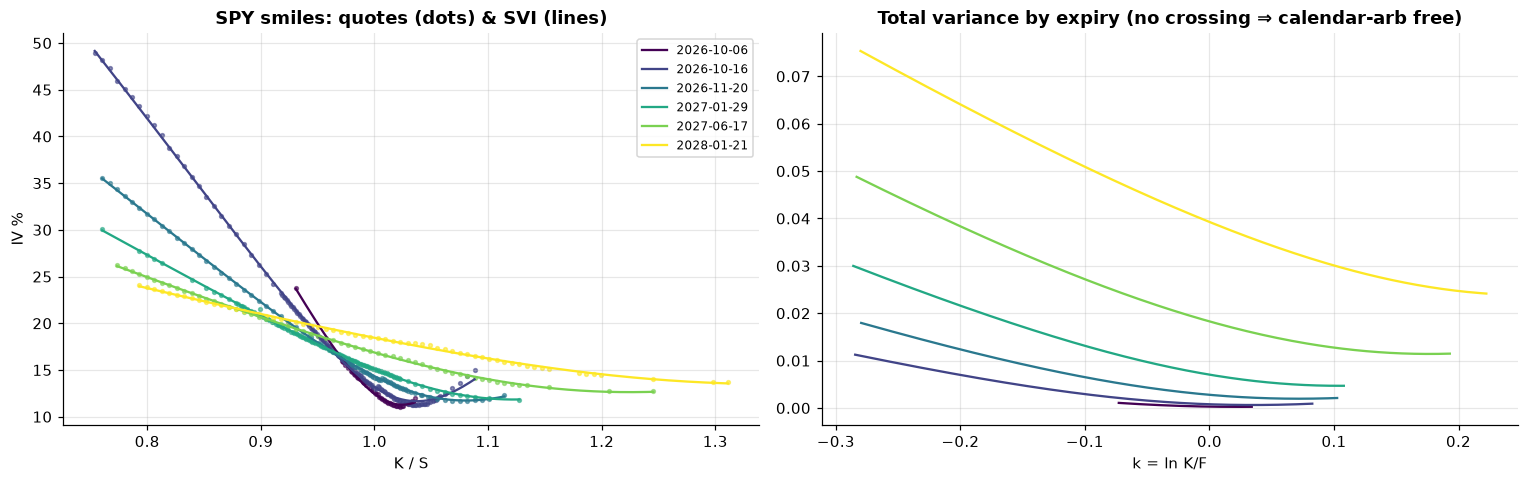

In [22]:
if LIVE:
    lsurf, st = svi_from_quotes(ms)
    fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
    for i, ((T, g), p_) in enumerate(zip(ms.quotes.groupby("T"), lsurf.params)):
        col = cm.viridis(i/max(len(lsurf.params)-1, 1))
        F = g.F.iloc[0]; kq = np.log(g.K/F); kk = np.linspace(kq.min(), kq.max(), 200)
        ax[0].scatter(g.K/ms.spot, 100*g.iv, s=6, color=col, alpha=0.6)
        ax[0].plot(np.exp(kk)*F/ms.spot, 100*np.sqrt(svi_w(kk, *p_)/T), color=col, label=g.expiry.iloc[0])
        ax[1].plot(kk, svi_w(kk, *p_), color=col)
    ax[0].set(title=f"{TICKER} smiles: quotes (dots) & SVI (lines)", xlabel="K / S", ylabel="IV %"); ax[0].legend(fontsize=8)
    ax[1].set(title="Total variance by expiry (no crossing ⇒ calendar-arb free)", xlabel="k = ln K/F")
    plt.tight_layout()
    for e, T, n, rm in st: print(f"  {e}  n={n:3d}  SVI RMSE {rm:.2f} vol pts")

HestonParams(v0=np.float64(0.02193467662533615), kappa=np.float64(1.6083299902903023), theta=np.float64(0.048259009157147405), xi=np.float64(0.4006372513781538), rho=np.float64(-0.9117307929207161)) 
RMSE 0.38 vol pts, Feller -0.005


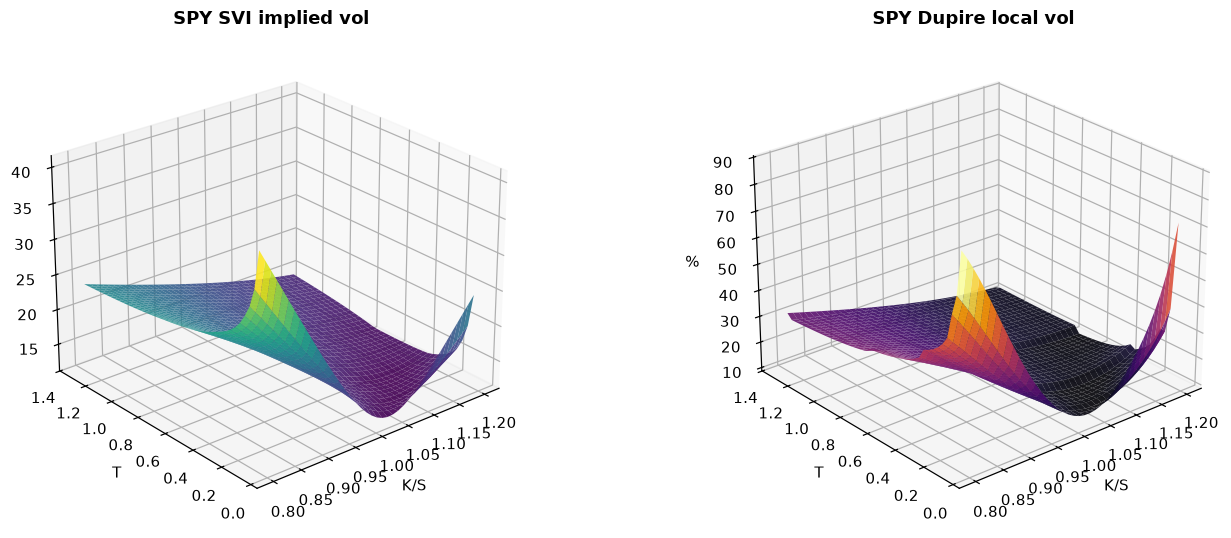

In [23]:
if LIVE:
    mats_l, strikes_l, grid_l = to_grid(ms)
    fit_l, rm = calibrate_heston(ms.spot, ms.r, ms.q, strikes_l, mats_l, grid_l,
                                 x0=[grid_l[0][4]**2, 2.0, grid_l[-1][4]**2, 0.8, -0.7])
    print(fit_l, f"\nRMSE {100*rm:.2f} vol pts, Feller {fit_l.feller():+.3f}")

    KK, TT = np.meshgrid(np.linspace(0.8, 1.2, 40)*ms.spot, np.linspace(0.05, lsurf.T[-1], 40))
    LVl = np.array([[lsurf.local_vol(K, T) for K in KK[0]] for T in TT[:, 0]])
    IVl = np.array([[lsurf.iv(K, T) for K in KK[0]] for T in TT[:, 0]])
    fig = plt.figure(figsize=(14, 5))
    for j, (Z, ttl, cmap) in enumerate([(IVl, "SVI implied vol", "viridis"), (LVl, "Dupire local vol", "inferno")]):
        ax = fig.add_subplot(1, 2, j+1, projection="3d")
        ax.plot_surface(KK/ms.spot, TT, 100*Z, cmap=cmap, alpha=0.9)
        ax.set(title=f"{TICKER} {ttl}", xlabel="K/S", ylabel="T", zlabel="%"); ax.view_init(25, -130)
    plt.tight_layout()

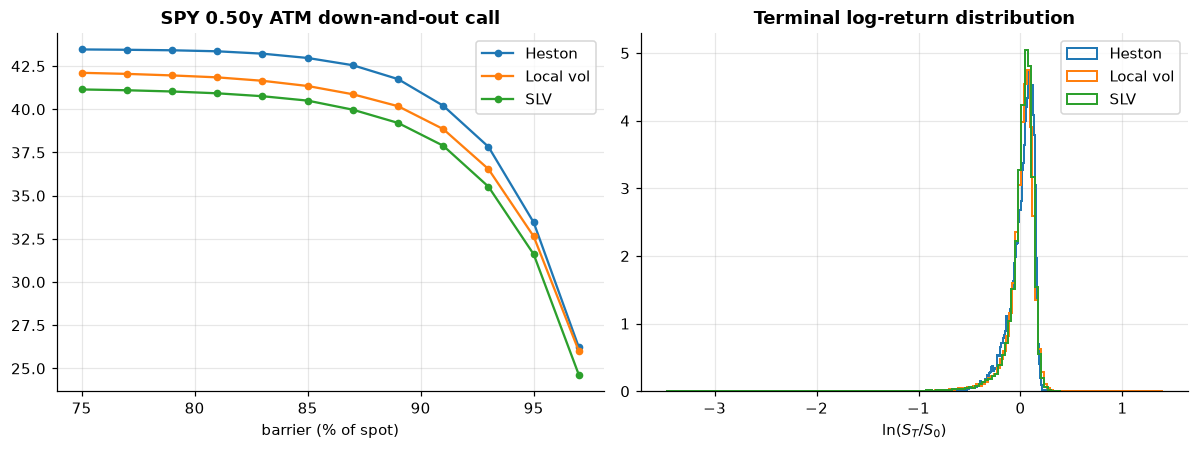

In [24]:
if LIVE:
    Sx, T1 = ms.spot, min(0.5, lsurf.T[-1])
    paths = {"Heston": heston_paths_qe(Sx, T1, ms.r, ms.q, fit_l, 30_000, 126),
             "Local vol": lv_paths(Sx, T1, ms.r, ms.q, lsurf, 30_000, 126),
             "SLV": slv_paths(Sx, T1, ms.r, ms.q, lsurf, fit_l, 30_000, 126)}
    bars = np.linspace(0.75, 0.97, 12)
    fig, ax = plt.subplots(1, 2)
    for i, (nm, P_) in enumerate(paths.items()):
        ax[0].plot(100*bars, [mc_price(P_, lambda X: np.where(X.min(1) > b*Sx, np.maximum(X[:, -1]-Sx, 0), 0), ms.r, T1)[0]
                              for b in bars], "o-", ms=4, color=C[i], label=nm)
        ax[1].hist(np.log(P_[:, -1]/Sx), bins=120, histtype="step", density=True, color=C[i], label=nm, lw=1.3)
    ax[0].set(title=f"{TICKER} {T1:.2f}y ATM down-and-out call", xlabel="barrier (% of spot)"); ax[0].legend()
    ax[1].set(title="Terminal log-return distribution", xlabel=r"$\ln(S_T/S_0)$"); ax[1].legend()
    plt.tight_layout()

### Reading the results

* **Heston** captures smile *dynamics* but can't fit every expiry simultaneously → its vanillas drift off the market.
* **Local vol** fits every vanilla exactly but its forward skew flattens — typically **over-values** down-and-out options (knock-outs too unlikely later).
* **SLV** keeps the exact vanilla fit *and* Heston's forward skew; the LV–SLV spread on a barrier is the model-risk reserve a desk would hold.

In [25]:
# ── shared imports for sections 13-16 ──
import quant_ext as qx
from quant_ext import (sabr_vol, sabr_calibrate, sabr_density, RBergomiParams, rbergomi_paths,
                       rbergomi_smile, atm_skew, estimate_hurst, NelsonSiegel, load_treasury_curve,
                       HullWhite, black_caplet_iv, cf_price, MertonParams, merton_cf, merton_series,
                       KouParams, kou_cf, merton_paths, calibrate_merton)
from scipy.optimize import least_squares
qx.RNG = np.random.default_rng(3)

## 13 · SABR — the market standard for rates & FX smiles

Stochastic **A**lpha **B**eta **R**ho (Hagan, Kumar, Lesniewski & Woodward 2002). Under the $T$-forward measure:

$$
dF_t = \alpha_t F_t^{\beta}\,dW_t,\qquad d\alpha_t = \nu\,\alpha_t\,dZ_t,\qquad d\langle W,Z\rangle_t=\rho\,dt
$$

Singular perturbation gives Hagan's celebrated implied-vol expansion:

$$
\sigma_B(K,F) \approx
\frac{\alpha}{(FK)^{\frac{1-\beta}{2}}\left[1+\frac{(1-\beta)^2}{24}\ln^2\!\frac FK+\frac{(1-\beta)^4}{1920}\ln^4\!\frac FK\right]}
\cdot\frac{z}{x(z)}\cdot
\left[1+\left(\frac{(1-\beta)^2\alpha^2}{24(FK)^{1-\beta}}+\frac{\rho\beta\nu\alpha}{4(FK)^{\frac{1-\beta}{2}}}+\frac{2-3\rho^2}{24}\nu^2\right)T\right]
$$

$$
z=\frac{\nu}{\alpha}(FK)^{\frac{1-\beta}{2}}\ln\frac FK,\qquad
x(z)=\ln\!\left(\frac{\sqrt{1-2\rho z+z^2}+z-\rho}{1-\rho}\right)
$$

* $\beta$ sets the **backbone** — how ATM vol moves with the forward: $\sigma_{\text{ATM}}\approx \alpha/F^{1-\beta}$.
* $\rho$ tilts the smile (skew); $\nu$ bends it (curvature).
* Weakness: the expansion admits **negative densities** at low strikes / long expiries (fixed by arbitrage-free SABR / PDE methods).

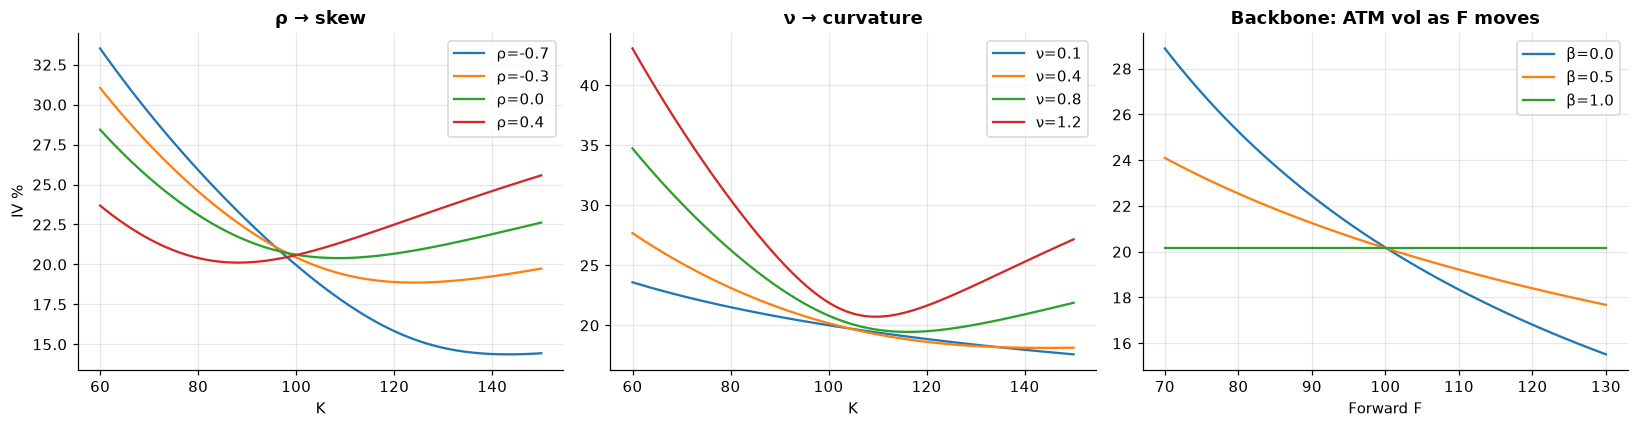

In [26]:
F0, Ks13 = 100.0, np.linspace(60, 150, 100)
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
a05 = 0.2 * F0**0.5
for i, rho in enumerate([-0.7, -0.3, 0.0, 0.4]):
    ax[0].plot(Ks13, 100*sabr_vol(F0, Ks13, 1, a05, 0.5, rho, 0.6), color=C[i], label=f"ρ={rho}")
for i, nu in enumerate([0.1, 0.4, 0.8, 1.2]):
    ax[1].plot(Ks13, 100*sabr_vol(F0, Ks13, 1, a05, 0.5, -0.3, nu), color=C[i], label=f"ν={nu}")
Fs = np.linspace(70, 130, 60)
for i, beta in enumerate([0.0, 0.5, 1.0]):
    a = 0.2 * F0**(1-beta)
    ax[2].plot(Fs, 100*sabr_vol(Fs, Fs, 1, a, beta, 0.0, 0.3), color=C[i], label=f"β={beta}")
ax[0].set(title="ρ → skew", xlabel="K", ylabel="IV %"); ax[1].set(title="ν → curvature", xlabel="K")
ax[2].set(title="Backbone: ATM vol as F moves", xlabel="Forward F")
for a in ax: a.legend()
plt.tight_layout()

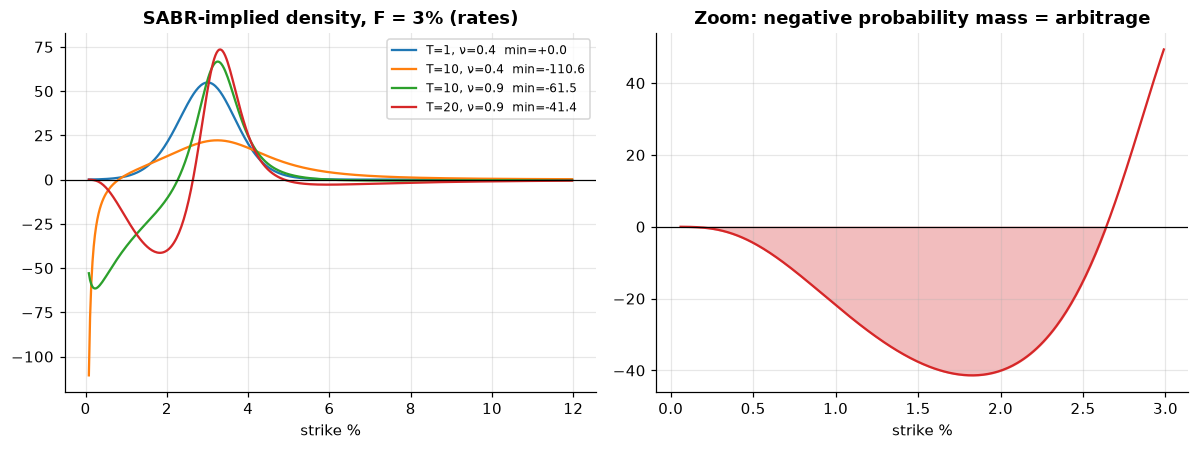

In [27]:
# Hagan's formula is an asymptotic expansion — push it and the implied density goes negative
fig, ax = plt.subplots(1, 2)
for i, (T_, nu) in enumerate([(1, 0.4), (10, 0.4), (10, 0.9), (20, 0.9)]):
    k, dens = sabr_density(0.03, T_, 0.03**0.5*0.25, 0.5, -0.3, nu, np.linspace(0.0005, 0.12, 400))
    ax[0].plot(100*k, dens, color=C[i], label=f"T={T_}, ν={nu}  min={dens.min():+.1f}")
ax[0].axhline(0, color="k", lw=0.8); ax[0].set(title="SABR-implied density, F = 3% (rates)", xlabel="strike %"); ax[0].legend(fontsize=8)
k, dens = sabr_density(0.03, 20, 0.03**0.5*0.25, 0.5, -0.3, 0.9, np.linspace(0.0005, 0.03, 300))
ax[1].plot(100*k, dens, color=C[3]); ax[1].fill_between(100*k, dens, 0, where=dens < 0, color=C[3], alpha=0.3)
ax[1].axhline(0, color="k", lw=0.8); ax[1].set(title="Zoom: negative probability mass = arbitrage", xlabel="strike %")
plt.tight_layout()

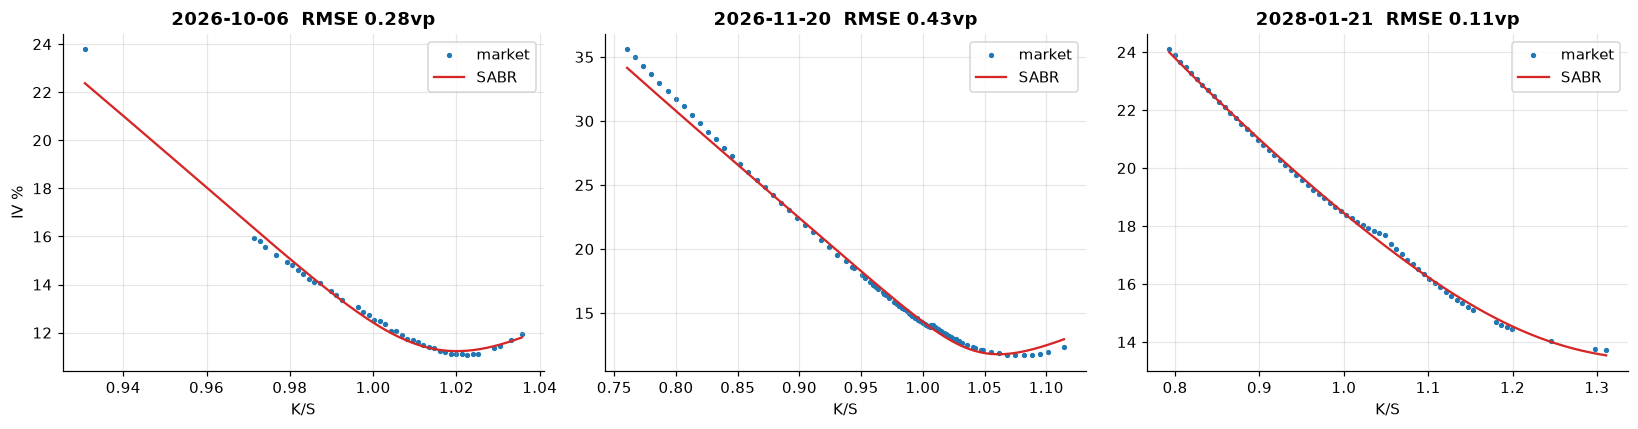

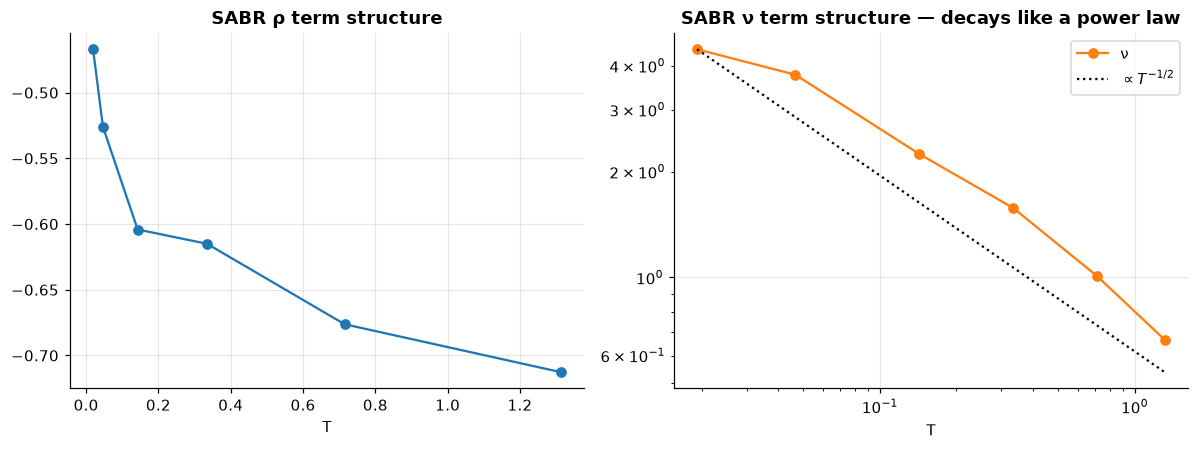

In [28]:
# Calibrate SABR (β = 1, standard for equity) slice-by-slice to the live chain
if LIVE:
    rows = []
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for i, (T_, g) in enumerate(ms.quotes.groupby("T")):
        F_ = g.F.iloc[0]; K_ = g.K.values; iv_ = g.iv.values
        w_ = np.exp(-0.5*(np.log(K_/F_)/(0.25*np.sqrt(T_)+0.05))**2) + 0.2
        (a_, r_, n_), err = sabr_calibrate(F_, K_, T_, iv_, beta=1.0, w=w_)
        rows.append((T_, a_, r_, n_, err))
        if i in (0, 2, len(ms.quotes["T"].unique())-1):
            ax = axes[[0, 2, len(ms.quotes["T"].unique())-1].index(i)]
            kk = np.linspace(K_.min(), K_.max(), 200)
            ax.scatter(K_/ms.spot, 100*iv_, s=6, color=C[0], label="market")
            ax.plot(kk/ms.spot, 100*sabr_vol(F_, kk, T_, a_, 1.0, r_, n_), color=C[3], label="SABR")
            ax.set(title=f"{g.expiry.iloc[0]}  RMSE {100*err:.2f}vp", xlabel="K/S"); ax.legend()
    axes[0].set_ylabel("IV %"); plt.tight_layout()
    rows = np.array(rows)
    fig, ax = plt.subplots(1, 2)
    ax[0].plot(rows[:, 0], rows[:, 2], "o-", label="ρ"); ax[0].set(title="SABR ρ term structure", xlabel="T")
    ax[1].loglog(rows[:, 0], rows[:, 3], "o-", color=C[1], label="ν")
    ax[1].loglog(rows[:, 0], rows[0, 3]*(rows[:, 0]/rows[0, 0])**-0.5, "k:", label=r"$\propto T^{-1/2}$")
    ax[1].set(title="SABR ν term structure — decays like a power law", xlabel="T"); ax[1].legend()
    plt.tight_layout()

## 14 · Rough volatility — the rough Bergomi model

Gatheral, Jaisson & Rosenbaum (2018): log-volatility behaves like fractional Brownian motion with **Hurst exponent $H\approx0.1$**, far rougher than Brownian motion ($H=\tfrac12$). The rough Bergomi model (Bayer, Friz & Gatheral 2016):

$$
v_t = \xi_0(t)\,\exp\!\left(\eta\,\tilde W^H_t - \tfrac12\eta^2 t^{2H}\right),\qquad
\tilde W^H_t = \sqrt{2H}\int_0^t (t-s)^{H-\frac12}\,dW_s,
$$
$$
\frac{dS_t}{S_t} = \sqrt{v_t}\left(\rho\,dW_t + \sqrt{1-\rho^2}\,dW^\perp_t\right).
$$

$\tilde W^H$ is a Riemann–Liouville fBm — Gaussian, so the pair $(\tilde W^H, W)$ can be simulated **exactly** by Cholesky on a grid, using

$$
\mathrm{Cov}(\tilde W^H_u, \tilde W^H_v) = \frac{2H\,u^{H+\frac12}(v-u)^{H-\frac12}}{H+\tfrac12}\;{}_2F_1\!\left(\tfrac12-H,\;H+\tfrac12;\;H+\tfrac32;\;-\tfrac{u}{v-u}\right),\qquad
\mathrm{Cov}(\tilde W^H_v, W_u) = \frac{\sqrt{2H}}{H+\tfrac12}\left[v^{H+\frac12}-(v-u\wedge v)^{H+\frac12}\right].
$$

The signature prediction is the **ATM skew power law**, which classical diffusions cannot produce:

$$
\psi(T) := \left|\frac{\partial\sigma_{\text{BS}}(k,T)}{\partial k}\right|_{k=0} \;\propto\; T^{H-\frac12}\quad (T\to0),
\qquad\text{vs. Heston: } \psi(T)\to\text{const}.
$$

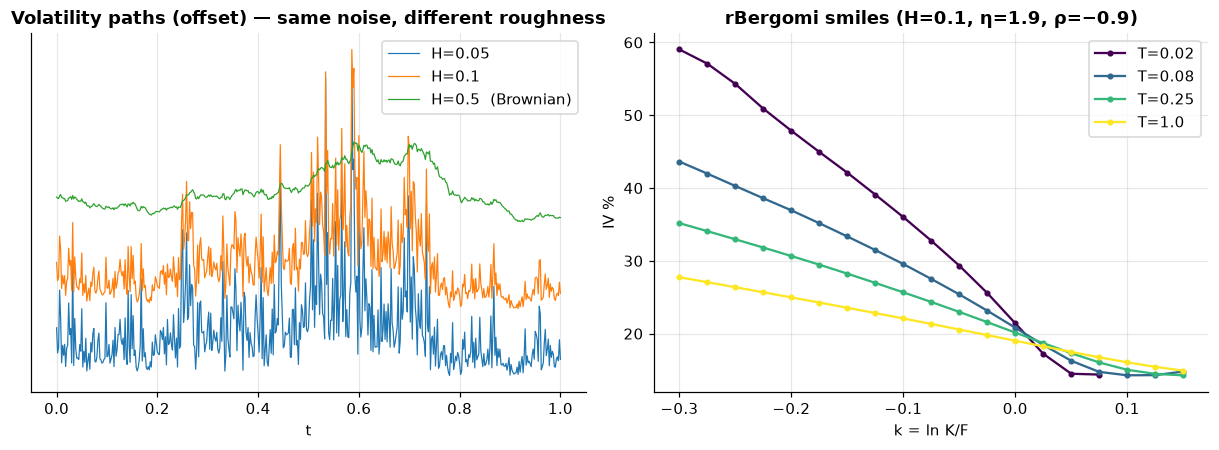

In [29]:
fig, ax = plt.subplots(1, 2)
for i, H in enumerate([0.05, 0.1, 0.5]):
    _, Vr = rbergomi_paths(100, 1.0, RBergomiParams(H, 1.5, -0.7, 0.04), n_paths=1, n_steps=500, seed=4, return_var=True)
    ax[0].plot(np.linspace(0, 1, 501), np.sqrt(Vr[0]) + 0.25*i, color=C[i], lw=0.8, label=f"H={H}" + ("  (Brownian)" if H == 0.5 else ""))
ax[0].set(title="Volatility paths (offset) — same noise, different roughness", xlabel="t", yticks=[]); ax[0].legend()

rb = RBergomiParams(H=0.1, eta=1.9, rho=-0.9, xi0=0.235**2)
ks = np.linspace(-0.3, 0.15, 19)
for i, T_ in enumerate([0.02, 0.08, 0.25, 1.0]):
    iv = rbergomi_smile(100, 100*np.exp(ks), T_, rb, n_paths=40_000)
    ax[1].plot(ks, 100*iv, "o-", ms=3, color=cm.viridis(i/3), label=f"T={T_}")
ax[1].set(title="rBergomi smiles (H=0.1, η=1.9, ρ=−0.9)", xlabel="k = ln K/F", ylabel="IV %"); ax[1].legend()
plt.tight_layout()

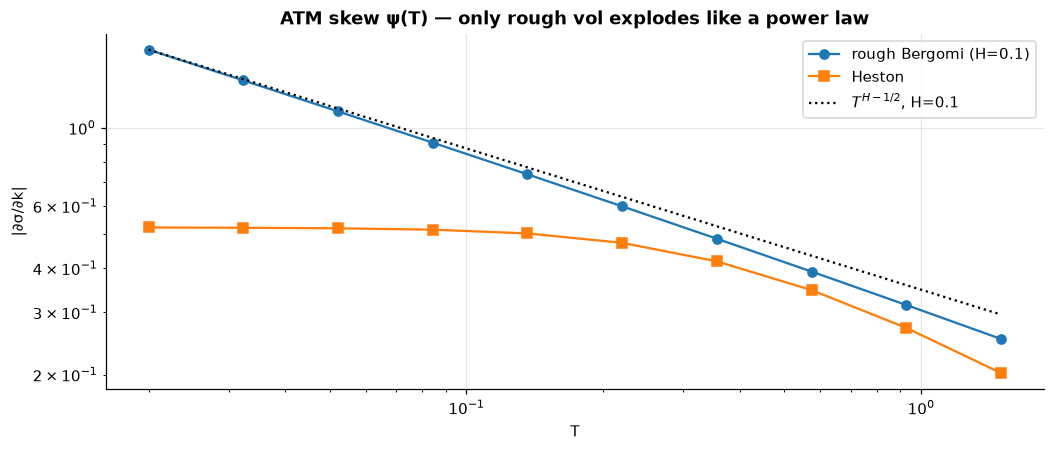

In [30]:
# ATM skew term structure: rough vs Heston
Tg = np.geomspace(0.02, 1.5, 10); dk = 0.02
def fd_skew(iv_fn, T_):  # central difference in log-moneyness, F = S = 100, r = q = 0
    return abs(iv_fn(100*np.exp(dk), T_) - iv_fn(100*np.exp(-dk), T_)) / (2*dk)
h_iv = lambda K, T_: implied_vol(heston_price(100, K, T_, 0, 0, true, 1 if K >= 100 else -1), 100, K, T_, 0, 0, 1 if K >= 100 else -1)
sk_h = [fd_skew(h_iv, T_) for T_ in Tg]
sk_r = [abs(np.diff(rbergomi_smile(100, 100*np.exp([-dk, dk]), T_, rb, n_paths=80_000))[0])/(2*dk) for T_ in Tg]

plt.loglog(Tg, sk_r, "o-", label="rough Bergomi (H=0.1)")
plt.loglog(Tg, sk_h, "s-", label="Heston")
plt.loglog(Tg, sk_r[0]*(Tg/Tg[0])**(0.1-0.5), "k:", label=r"$T^{H-1/2}$, H=0.1")
plt.title("ATM skew ψ(T) — only rough vol explodes like a power law"); plt.xlabel("T"); plt.ylabel("|∂σ/∂k|"); plt.legend();

Market ATM-skew slope -0.269  ⇒  H ≈ 0.231


Calibrated η = 1.34, ρ = -0.79  (H fixed at 0.231)


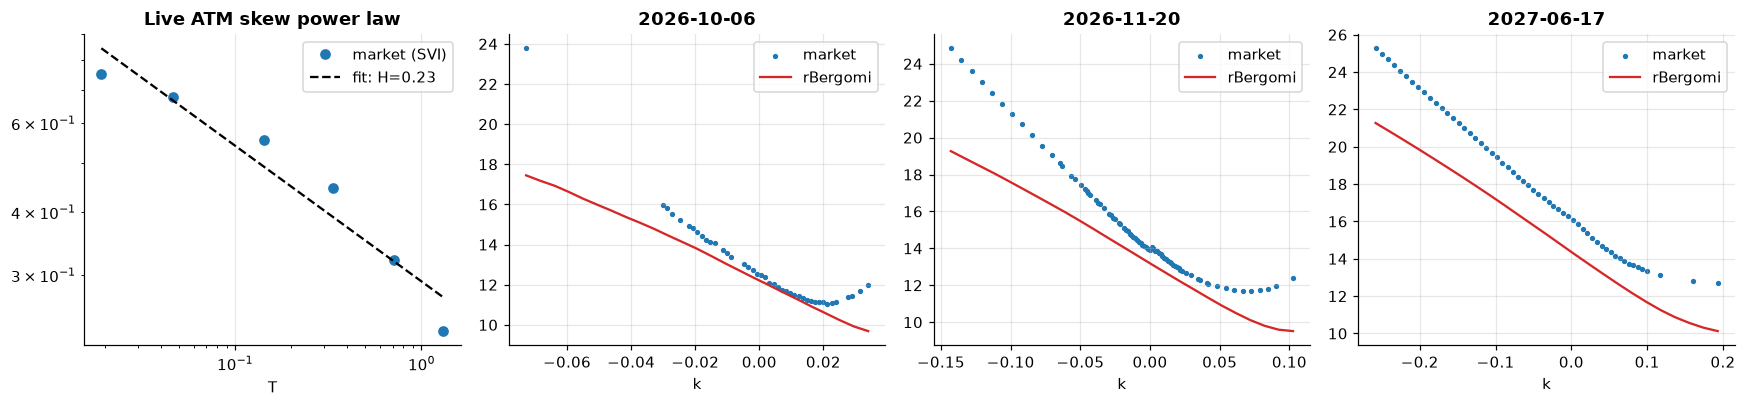

In [31]:
# Estimate H from the live market's ATM skew term structure, then calibrate (η, ρ)
if LIVE:
    Ts_, psi_ = [], []
    for T_, p_ in zip(lsurf.T, lsurf.params):
        kk = np.linspace(-0.05, 0.05, 41)
        ivk = np.sqrt(svi_w(kk, *p_)/T_)
        Ts_.append(T_); psi_.append(abs(np.polyfit(kk, ivk, 1)[0]))
    Ts_, psi_ = np.array(Ts_), np.array(psi_)
    H_hat, slope, icpt = estimate_hurst(Ts_, psi_)
    print(f"Market ATM-skew slope {slope:+.3f}  ⇒  H ≈ {H_hat:.3f}")

    g0 = [g for _, g in ms.quotes.groupby("T")]
    tgt = [(g["T"].iloc[0], g.F.iloc[0], g[(np.abs(np.log(g.K/g.F)) < 0.25*np.sqrt(g["T"].iloc[0])+0.05)]) for g in (g0[0], g0[2], g0[-2])]
    H_fit = float(np.clip(H_hat, 0.03, 0.45))
    def res(x):
        out = []
        for T_, F_, g in tgt:
            p_ = RBergomiParams(H_fit, x[0], x[1], np.interp(0, np.log(g.K/F_), g.iv)**2)
            kk = np.log(g.K.values/F_)
            out.append(rbergomi_smile(100, 100*np.exp(kk), T_, p_, n_paths=15_000, n_steps=48) - g.iv.values)
        return np.nan_to_num(np.concatenate(out), nan=0.05) * 100
    sol = least_squares(res, [1.5, -0.8], bounds=([0.2, -0.99], [5, 0.0]), diff_step=0.05, max_nfev=25)
    eta_hat, rho_hat = sol.x
    print(f"Calibrated η = {eta_hat:.2f}, ρ = {rho_hat:+.2f}  (H fixed at {H_fit:.3f})")

    fig, ax = plt.subplots(1, 4, figsize=(16, 3.8))
    ax[0].loglog(Ts_, psi_, "o", label="market (SVI)"); ax[0].loglog(Ts_, np.exp(icpt)*Ts_**slope, "k--", label=f"fit: H={H_hat:.2f}")
    ax[0].set(title="Live ATM skew power law", xlabel="T"); ax[0].legend()
    for a, (T_, F_, g) in zip(ax[1:], tgt):
        kk = np.linspace(np.log(g.K/F_).min(), np.log(g.K/F_).max(), 25)
        p_ = RBergomiParams(H_fit, eta_hat, rho_hat, np.interp(0, np.log(g.K/F_), g.iv)**2)
        a.scatter(np.log(g.K/F_), 100*g.iv, s=6, label="market")
        a.plot(kk, 100*rbergomi_smile(100, 100*np.exp(kk), T_, p_, n_paths=40_000, n_steps=64), color=C[3], label="rBergomi")
        a.set(title=f"{g.expiry.iloc[0]}", xlabel="k"); a.legend()
    plt.tight_layout()

## 15 · Interest rates — the Hull–White one-factor model

The short rate is a mean-reverting Gaussian process whose drift $\theta(t)$ is chosen to fit today's curve **exactly**:

$$
dr_t = \big(\theta(t) - a\,r_t\big)\,dt + \sigma\,dW_t,\qquad
\theta(t) = \partial_t f(0,t) + a\,f(0,t) + \frac{\sigma^2}{2a}\left(1-e^{-2at}\right)
$$

Equivalently $r_t = x_t + \alpha(t)$ with $dx_t=-a\,x_t\,dt+\sigma\,dW_t,\ x_0=0$ and $\alpha(t)=f(0,t)+\frac{\sigma^2}{2a^2}(1-e^{-at})^2$ — which we simulate **exactly**.

**Affine bond prices**

$$
P(t,T) = A(t,T)\,e^{-B(t,T)\,r_t},\qquad B(t,T)=\frac{1-e^{-a(T-t)}}{a},
$$
$$
A(t,T)=\frac{P(0,T)}{P(0,t)}\exp\!\left(B(t,T)f(0,t)-\frac{\sigma^2}{4a}\left(1-e^{-2at}\right)B(t,T)^2\right).
$$

**Zero-bond options** are Black-like, with $\sigma_P=\sigma\sqrt{\tfrac{1-e^{-2aT}}{2a}}\,B(T,S)$ and $h=\frac1{\sigma_P}\ln\frac{P(0,S)}{P(0,T)X}+\frac{\sigma_P}{2}$:

$$
\mathrm{ZBC}(T,S,X) = P(0,S)N(h) - X\,P(0,T)\,N(h-\sigma_P).
$$

* **Caplet** $=(1+\tau K)\,\mathrm{ZBP}\big(T,\,T+\tau,\,\tfrac1{1+\tau K}\big)$
* **Swaption** via **Jamshidian's trick**: find $r^*$ with $\sum_i c_iA(T_0,T_i)e^{-B(T_0,T_i)r^*}=1$; then $\text{Payer}=\sum_i c_i\,\mathrm{ZBP}(T_0,T_i,X_i)$ with $X_i=P(T_0,T_i;r^*)$.

The curve is a **Nelson–Siegel** fit to live Treasury yields: $\;y(T)=\beta_0+\beta_1\frac{1-e^{-T/\tau}}{T/\tau}+\beta_2\left(\frac{1-e^{-T/\tau}}{T/\tau}-e^{-T/\tau}\right)$.

Live Treasury yields: {np.float64(0.25): np.float64(4.049), np.float64(5.0): np.float64(5.036), np.float64(10.0): np.float64(5.216), np.float64(30.0): np.float64(5.54)}


MC vs curve discount factors: T=1: 0.9579/0.9579, T=3: 0.8674/0.8673, T=5: 0.7791/0.7789, T=10: 0.5904/0.5896


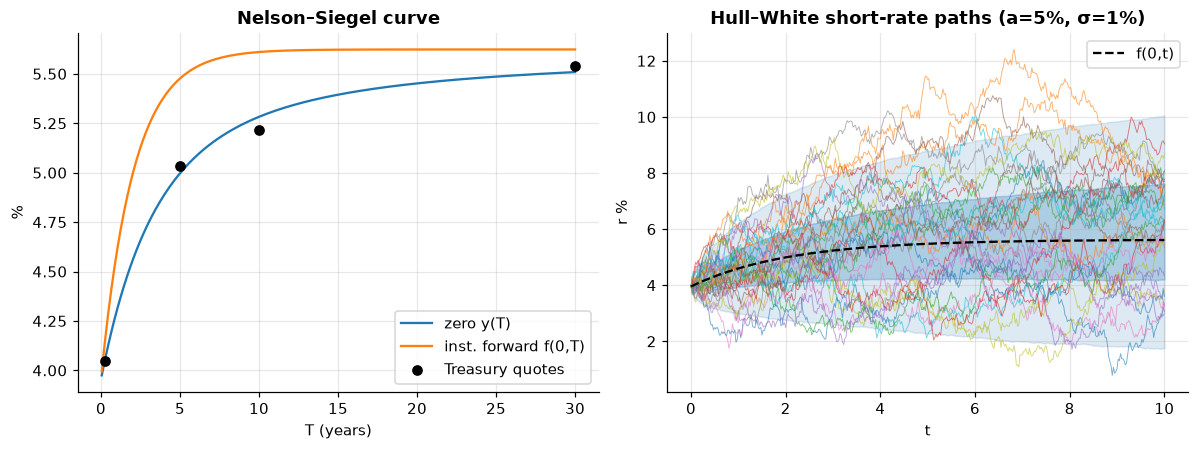

In [32]:
Tt, yt, live_curve = load_treasury_curve()
curve = NelsonSiegel.fit(Tt, yt)
print(("Live" if live_curve else "Fallback") + " Treasury yields:", dict(zip(Tt, np.round(100*yt, 3))))
hw = HullWhite(a=0.05, sigma=0.01, curve=curve)

TT = np.linspace(0.05, 30, 300)
fig, ax = plt.subplots(1, 2)
ax[0].plot(TT, 100*curve.zero(TT), label="zero y(T)"); ax[0].plot(TT, 100*curve.fwd(TT), label="inst. forward f(0,T)")
ax[0].scatter(Tt, 100*yt, color="k", zorder=3, label="Treasury quotes")
ax[0].set(title="Nelson–Siegel curve", xlabel="T (years)", ylabel="%"); ax[0].legend()

t_, r_, disc = hw.paths(10, 400, 20_000)
for i in range(30): ax[1].plot(t_, 100*r_[i], lw=0.6, alpha=0.6)
for lo, hi, a_ in [(5, 95, 0.15), (25, 75, 0.25)]:
    ax[1].fill_between(t_, 100*np.percentile(r_, lo, 0), 100*np.percentile(r_, hi, 0), color=C[0], alpha=a_)
ax[1].plot(t_, 100*curve.fwd(t_), "k--", label="f(0,t)")
ax[1].set(title="Hull–White short-rate paths (a=5%, σ=1%)", xlabel="t", ylabel="r %"); ax[1].legend()
plt.tight_layout()

mc_P = disc.mean(0); idx = [40, 120, 200, 400]
print("MC vs curve discount factors:", ", ".join(f"T={t_[i]:.0f}: {mc_P[i]:.4f}/{curve.P(t_[i]):.4f}" for i in idx))

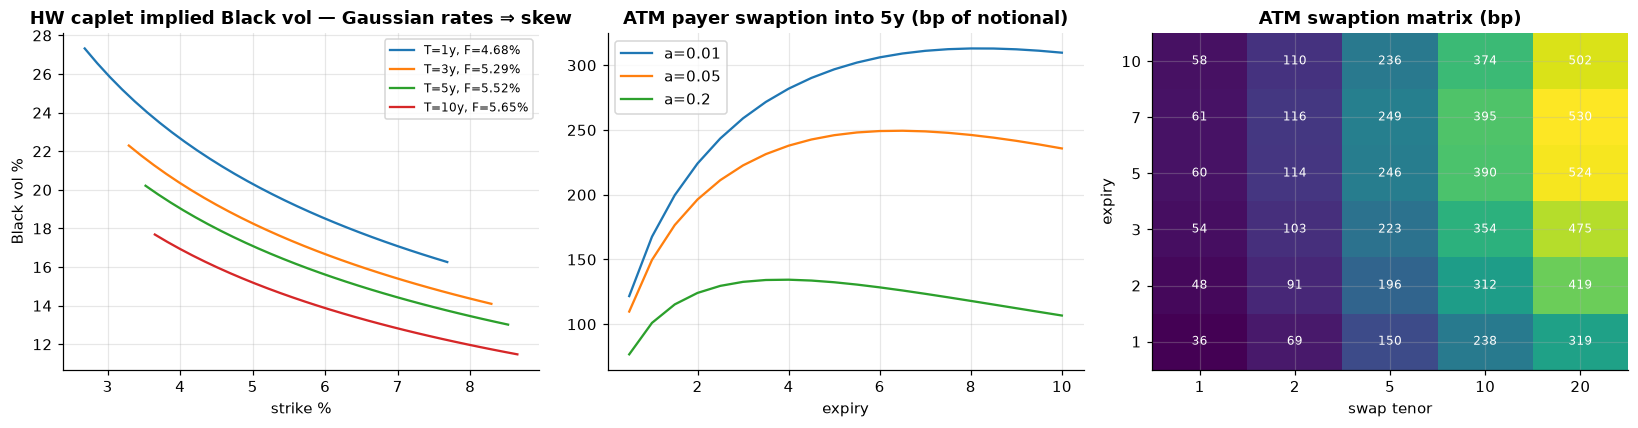

In [33]:
# Caplet Black-vol smile and swaption surface
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
tau = 0.25
for i, T_ in enumerate([1, 3, 5, 10]):
    P1, P2 = curve.P(T_), curve.P(T_ + tau); Fw = (P1/P2 - 1)/tau
    Ks_ = Fw + np.linspace(-0.02, 0.03, 30); Ks_ = Ks_[Ks_ > 0.002]
    ivs = [black_caplet_iv(hw.caplet(T_, tau, K), Fw, K, T_, tau, P2) for K in Ks_]
    ax[0].plot(100*Ks_, 100*np.array(ivs), color=C[i], label=f"T={T_}y, F={100*Fw:.2f}%")
ax[0].set(title="HW caplet implied Black vol — Gaussian rates ⇒ skew", xlabel="strike %", ylabel="Black vol %"); ax[0].legend(fontsize=8)

for i, a_ in enumerate([0.01, 0.05, 0.2]):
    h_ = HullWhite(a_, 0.01, curve)
    exps = np.linspace(0.5, 10, 20)
    ax[1].plot(exps, [1e4*h_.swaption(e, 5, h_.par_swap(e, 5)) for e in exps], color=C[i], label=f"a={a_}")
ax[1].set(title="ATM payer swaption into 5y (bp of notional)", xlabel="expiry"); ax[1].legend()

E_, N_ = np.array([1, 2, 3, 5, 7, 10]), np.array([1, 2, 5, 10, 20])
grid = np.array([[1e4*hw.swaption(e, n, hw.par_swap(e, n)) for n in N_] for e in E_])
im = ax[2].imshow(grid, cmap="viridis", origin="lower", aspect="auto")
ax[2].set(xticks=range(len(N_)), xticklabels=N_, yticks=range(len(E_)), yticklabels=E_,
          title="ATM swaption matrix (bp)", xlabel="swap tenor", ylabel="expiry")
for (j, k), v in np.ndenumerate(grid): ax[2].text(k, j, f"{v:.0f}", ha="center", va="center", color="w", fontsize=8)
plt.tight_layout()

In [34]:
# Validate Jamshidian against Monte Carlo: 5y × 5y payer at the money
T0, ten = 5.0, 5
K_ = hw.par_swap(T0, ten)
t_, r_, disc = hw.paths(T0, 250, 100_000)
Ti = T0 + np.arange(1, ten + 1)
bonds = np.array([hw.P(T0, T_, r_[:, -1]) for T_ in Ti]).T
payoff = np.maximum(1 - bonds[:, -1] - K_*bonds.sum(1), 0) * disc[:, -1]
print(f"5y×5y ATM payer (K={100*K_:.3f}%):  Jamshidian {1e4*hw.swaption(T0, ten, K_):.2f} bp   "
      f"MC {1e4*payoff.mean():.2f} ± {1.96e4*payoff.std()/np.sqrt(len(payoff)):.2f} bp")

5y×5y ATM payer (K=5.723%):  Jamshidian 245.99 bp   MC 246.90 ± 2.01 bp


## 16 · Jump-diffusion — Merton (1976) and Kou (2002)

Diffusions can't crash. Add a compound Poisson process with intensity $\lambda$ and jump sizes $Y$:

$$
\frac{dS_t}{S_{t^-}} = (r-q-\lambda\bar k)\,dt + \sigma\,dW_t + \left(e^{Y}-1\right)dN_t,\qquad \bar k = \mathbb{E}[e^Y]-1
$$

The compensator $-\lambda\bar k$ keeps $e^{-(r-q)t}S_t$ a martingale. By Lévy–Khintchine, the log-price characteristic function is

$$
\varphi_T(u) = \exp\!\Big(iu\big[\ln S_0 + (r-q-\lambda\bar k-\tfrac12\sigma^2)T\big] - \tfrac12\sigma^2u^2T + \lambda T\big(\phi_Y(u)-1\big)\Big)
$$

| | jump law | $\phi_Y(u)=\mathbb E[e^{iuY}]$ | $\bar k$ |
|---|---|---|---|
| **Merton** | $Y\sim\mathcal N(\mu_J,\delta^2)$ | $e^{iu\mu_J-\frac12\delta^2u^2}$ | $e^{\mu_J+\frac12\delta^2}-1$ |
| **Kou** | asymmetric double-exponential: $p\,\eta_1e^{-\eta_1y}\mathbf 1_{y>0}+(1-p)\,\eta_2e^{\eta_2y}\mathbf 1_{y<0}$ | $\frac{p\,\eta_1}{\eta_1-iu}+\frac{(1-p)\,\eta_2}{\eta_2+iu}$ | $\frac{p\eta_1}{\eta_1-1}+\frac{(1-p)\eta_2}{\eta_2+1}-1$ |

Merton also has a closed form as a **Poisson mixture of Black–Scholes prices**:

$$
C = \sum_{n=0}^{\infty}\frac{e^{-\lambda' T}(\lambda' T)^n}{n!}\,C_{\text{BS}}\!\left(S,K,T,\;r_n=r-\lambda\bar k+\tfrac{n\ln(1+\bar k)}{T},\;\sigma_n=\sqrt{\sigma^2+\tfrac{n\delta^2}{T}}\right),\qquad \lambda'=\lambda(1+\bar k).
$$

Jumps generate a steep **short-dated** skew that decays like $1/T$ — they are why 1-week SPX puts are so expensive.

Merton ATM 1y call:  Fourier 8.99126 | series 8.99126 | MC 9.0202 ± 0.1700


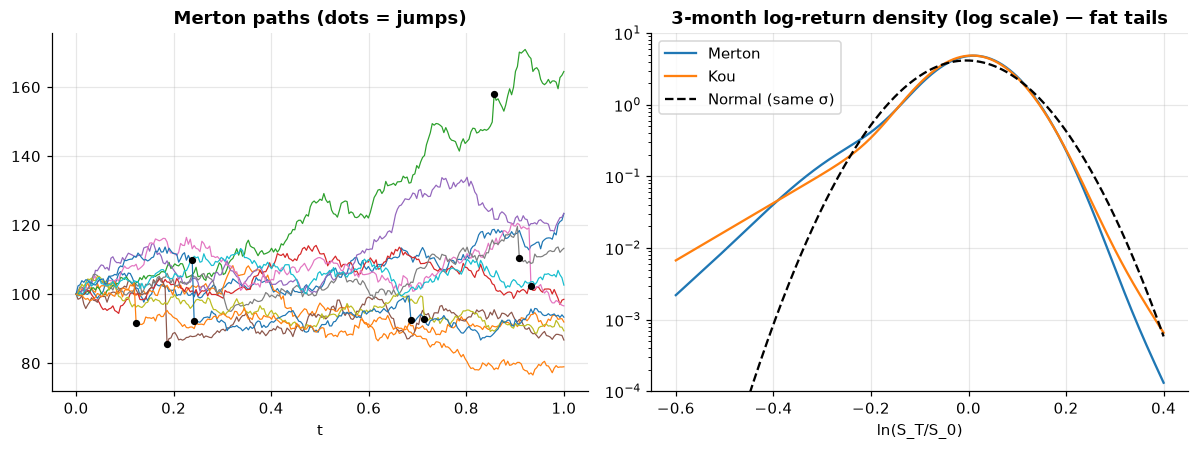

In [35]:
mp = MertonParams(sigma=0.15, lam=0.6, muJ=-0.12, delJ=0.10)
kp = KouParams(sigma=0.15, lam=1.0, p=0.3, eta1=25, eta2=10)
Pm, Nj = merton_paths(100, 1.0, r, q, mp, n_paths=20_000, n_steps=252)
cf_px = cf_price(merton_cf(100, 1.0, r, q, mp), 100, 100, 1.0, r, q)
se_px = merton_series(100, 100, 1.0, r, q, mp)
mc_px, mc_se = mc_price(Pm, lambda X: np.maximum(X[:, -1] - 100, 0), r, 1.0)
print(f"Merton ATM 1y call:  Fourier {cf_px:.5f} | series {se_px:.5f} | MC {mc_px:.4f} ± {1.96*mc_se:.4f}")

fig, ax = plt.subplots(1, 2)
tt = np.linspace(0, 1, 253)
for i in range(12):
    ax[0].plot(tt, Pm[i], lw=0.8, color=C[i % 10])
    jumps = np.where(Nj[i] > 0)[0]
    ax[0].scatter(tt[jumps + 1], Pm[i, jumps + 1], color="k", s=14, zorder=3)
ax[0].set(title="Merton paths (dots = jumps)", xlabel="t")

x = np.linspace(-0.6, 0.4, 400); dx = x[1] - x[0]
def density(cf_fn, T_):
    u = np.linspace(-300, 300, 6001); du = u[1] - u[0]
    phi = cf_fn(u) * np.exp(-1j*u*np.log(100))
    return np.array([(np.exp(-1j*u*xx)*phi).sum().real*du/(2*np.pi) for xx in x])
dm, dk_ = density(merton_cf(100, 0.25, 0, 0, mp), 0.25), density(kou_cf(100, 0.25, 0, 0, kp), 0.25)
sd = np.sqrt(np.sum(dm*x**2)*dx - (np.sum(dm*x)*dx)**2)
ax[1].semilogy(x, np.maximum(dm, 1e-8), label="Merton"); ax[1].semilogy(x, np.maximum(dk_, 1e-8), label="Kou")
ax[1].semilogy(x, norm.pdf(x, np.sum(dm*x)*dx, sd), "k--", label="Normal (same σ)")
ax[1].set(ylim=(1e-4, 10), title="3-month log-return density (log scale) — fat tails", xlabel="ln(S_T/S_0)"); ax[1].legend()
plt.tight_layout()

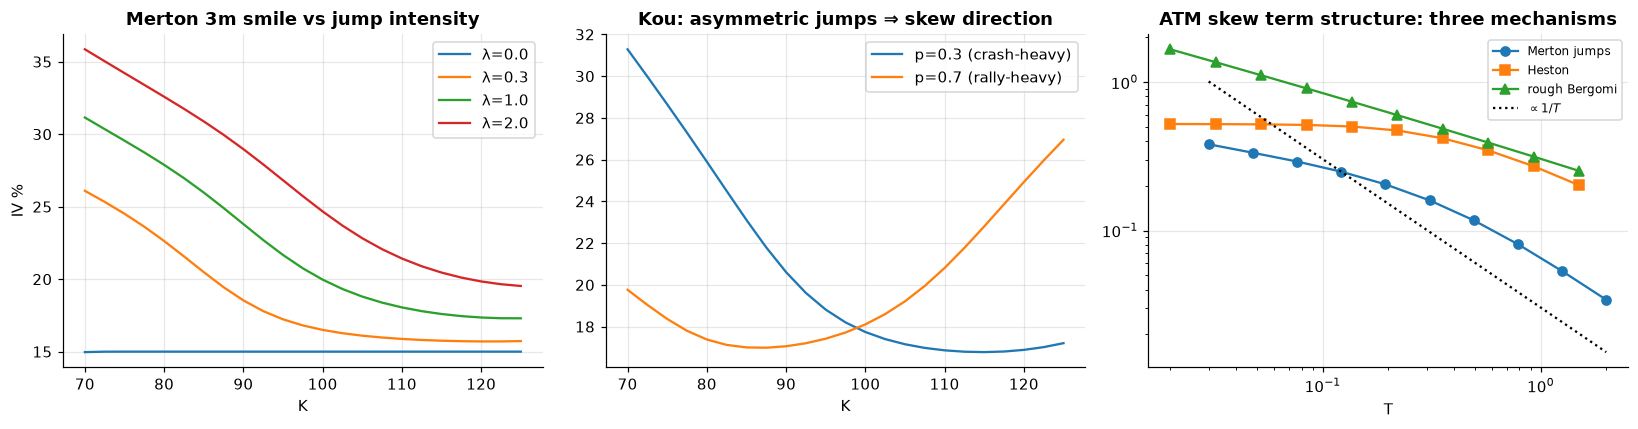

In [36]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
Ks16 = np.linspace(70, 125, 23)
for i, lam in enumerate([0.0, 0.3, 1.0, 2.0]):
    p_ = MertonParams(0.15, lam, -0.12, 0.10)
    ivs = [implied_vol(cf_price(merton_cf(100, 0.25, r, q, p_), 100, K, 0.25, r, q, 1 if K >= 100 else -1), 100, K, 0.25, r, q, 1 if K >= 100 else -1) for K in Ks16]
    ax[0].plot(Ks16, 100*np.array(ivs), color=C[i], label=f"λ={lam}")
ax[0].set(title="Merton 3m smile vs jump intensity", xlabel="K", ylabel="IV %"); ax[0].legend()

for i, (lab, p_) in enumerate([("p=0.3 (crash-heavy)", kp), ("p=0.7 (rally-heavy)", KouParams(0.15, 1.0, 0.7, 10, 25))]):
    ivs = [implied_vol(cf_price(kou_cf(100, 0.25, r, q, p_), 100, K, 0.25, r, q, 1 if K >= 100 else -1), 100, K, 0.25, r, q, 1 if K >= 100 else -1) for K in Ks16]
    ax[1].plot(Ks16, 100*np.array(ivs), color=C[i], label=lab)
ax[1].set(title="Kou: asymmetric jumps ⇒ skew direction", xlabel="K"); ax[1].legend()

Tg2 = np.geomspace(0.03, 2, 10)
m_iv = lambda K, T_: implied_vol(cf_price(merton_cf(100, T_, 0, 0, mp), 100, K, T_, 0, 0, 1 if K >= 100 else -1), 100, K, T_, 0, 0, 1 if K >= 100 else -1)
ax[2].loglog(Tg2, [fd_skew(m_iv, T_) for T_ in Tg2], "o-", label="Merton jumps")
ax[2].loglog(Tg, sk_h, "s-", label="Heston"); ax[2].loglog(Tg, sk_r, "^-", label="rough Bergomi")
ax[2].loglog(Tg2, fd_skew(m_iv, Tg2[3])*Tg2[3]/Tg2, "k:", label=r"$\propto 1/T$")
ax[2].set(title="ATM skew term structure: three mechanisms", xlabel="T"); ax[2].legend(fontsize=8)
plt.tight_layout()

Merton fit: σ=0.102  λ=3.66/yr  μ_J=-0.034  δ=0.039  (mean jump -3.3%, RMSE 1.01 vol pts)


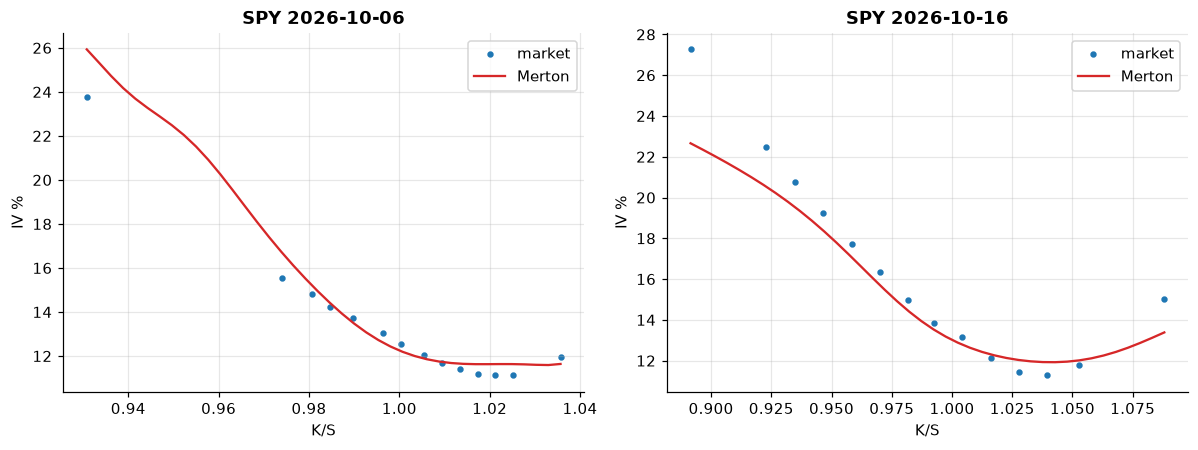

In [37]:
# Calibrate Merton to the two shortest live expiries (where jumps matter most)
if LIVE:
    sel = []
    for T_, g in list(ms.quotes.groupby("T"))[:2]:
        g = g[np.abs(np.log(g.K/g.F)) < 0.12]
        g = g.iloc[np.linspace(0, len(g)-1, min(14, len(g))).astype(int)]
        sel.append((T_, g))
    quotes = [(K, T_, iv, cp) for T_, g in sel for K, iv, cp in zip(g.K, g.iv, g.cp)]
    mfit, merr = calibrate_merton(ms.spot, ms.r, ms.q, quotes)
    print(f"Merton fit: σ={mfit.sigma:.3f}  λ={mfit.lam:.2f}/yr  μ_J={mfit.muJ:+.3f}  δ={mfit.delJ:.3f}  "
          f"(mean jump {100*mfit.kbar:+.1f}%, RMSE {100*merr:.2f} vol pts)")
    fig, ax = plt.subplots(1, 2)
    for a, (T_, g) in zip(ax, sel):
        Kg_ = np.linspace(g.K.min(), g.K.max(), 40)
        ivm = [implied_vol(cf_price(merton_cf(ms.spot, T_, ms.r, ms.q, mfit), ms.spot, K, T_, ms.r, ms.q,
                                    1 if K >= g.F.iloc[0] else -1), ms.spot, K, T_, ms.r, ms.q, 1 if K >= g.F.iloc[0] else -1) for K in Kg_]
        a.scatter(g.K/ms.spot, 100*g.iv, s=10, label="market"); a.plot(Kg_/ms.spot, 100*np.array(ivm), color=C[3], label="Merton")
        a.set(title=f"{TICKER} {g.expiry.iloc[0]}", xlabel="K/S", ylabel="IV %"); a.legend()
    plt.tight_layout()

### Which model when?

| Model | Fits today's smile | Smile dynamics | Short-dated skew | Typical use |
|---|---|---|---|---|
| Black–Scholes | ✗ | ✗ | ✗ | Quoting convention, Greeks |
| Heston | ~ | ✓ | ✗ (flat) | Long-dated equity/FX exotics |
| SABR | ✓ per slice | ✓ backbone | ~ | Rates & FX vanillas, CMS |
| Rough Bergomi | ✓ with few params | ✓ | ✓ $T^{H-1/2}$ | VIX / short-dated SPX |
| Merton / Kou | ~ | ~ | ✓ $1/T$ | Crash risk, gap risk |
| Local vol | ✓ exact | ✗ (flattens) | ✓ | Vanilla-consistent pricing |
| SLV | ✓ exact | ✓ | ✓ | Barrier & path-dependent exotics |
| Hull–White | curve exact | Gaussian rates | — | Bermudans, callable bonds, XVA |